# METEOR Description Paper: Seasonal and Noise Model Visualization

This notebook illustrates the capabilities of METEOR for generating ensemble members that combine seasonal patterns with realistic noise structures. We start with a global mean temperature plot comparing a 10-member METEOR ensemble for CESM2 RCP4.5 with the original experiment data.

## 1. Import Required Libraries

In [1]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Configure logging to see cache status
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# Third-party imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# METEOR import - import from the correct module
from meteor.meteor import Meteor as METEOR
import time
import meteor.prpatt as prpatt

from meteor import MeteorPatternScaling
import sys
from io import StringIO
import os
from ciceroscm import concentrations_emissions_handler, input_handler


## 2. Load Model Data from Cache

In [2]:
# Initialize CMIP6 data getter with cache enabled
from meteor import Cmip6MeteorDataGetter

# Set up the data getter for the experiments we need
# We'll use ssp245 (RCP4.5) along with piControl for the noise model
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["tas"],  # Surface air temperature
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'   ],  # Project names for each experiment
    enable_cache=True  # Use cached data
)

print("Data getter initialized successfully!")
print(f"Available models: {data_getter.get_models_avail()}")

INFO: Setting up local cache for CMIP6 data at: /Users/bensan/Documents/Github/METEOR/.cache/cmip6. This will improve performance by storing downloaded data locally.
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv


Data getter initialized successfully!
Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


## 4. Calculate Global Mean Temperature

In [3]:
def calculate_global_mean(data):
    """Calculate area-weighted global mean temperature."""
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    return data_weighted.mean(dim=["lat", "lon"])


## 3. Set Up Regional Analysis Tools

In [4]:
# Install and import regionmask for AR6 regional analysis
try:
    import regionmask
    print("✅ regionmask already installed")
except ImportError:
    print("📦 Installing regionmask...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regionmask", "-q"])
    import regionmask
    print("✅ regionmask installed successfully")

# Load AR6 regions
ar6_regions = regionmask.defined_regions.ar6.all
print(f"✅ AR6 regions loaded: {len(ar6_regions)} regions available")


✅ regionmask already installed
✅ AR6 regions loaded: 58 regions available


In [5]:
def calculate_regional_mean(data, region_code):
    """
    Calculate area-weighted regional mean for a specific AR6 region.
    
    Parameters
    ----------
    data : xr.DataArray
        Data with dimensions including 'lat' and 'lon'
    region_code : str
        AR6 region abbreviation (e.g., 'WNA', 'NEU', 'EAS', etc.)
    
    Returns
    -------
    xr.DataArray
        Regional mean time series
    """
    # Create mask for the specified region
    mask = ar6_regions.mask(data)
    
    # Find the region number for the given code
    region_number = None
    for region in ar6_regions:
        if region.abbrev == region_code:
            region_number = region.number
            region_name = region.name
            break
    
    if region_number is None:
        raise ValueError(f"Region code '{region_code}' not found in AR6 regions")
    
    # Apply mask to data
    regional_data = data.where(mask == region_number)
    
    # Calculate area-weighted mean
    weights = np.cos(np.deg2rad(regional_data.lat))
    weights.name = "weights"
    regional_weighted = regional_data.weighted(weights)
    regional_mean = regional_weighted.mean(dim=["lat", "lon"])
    
    # Add attributes
    regional_mean.attrs['region_code'] = region_code
    regional_mean.attrs['region_name'] = region_name
    
    return regional_mean


def list_ar6_regions():
    """List all available AR6 regions with their codes and names."""
    print("AR6 IPCC Reference Regions:")
    print("=" * 60)
    for region in ar6_regions:
        print(f"  {region.abbrev:6s} : {region.name}")
    print("=" * 60)
    print(f"Total: {len(ar6_regions)} regions")



print("\navailable regions:")
list_ar6_regions()


available regions:
AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian

## 5. Set Up Pattern Scaling Models

In [124]:
from scipy import stats

# =============================================================================
# PATH 1: 1D Transform (for regional/global mean time series)
# =============================================================================

def fit_distribution_parameters_1d(timeseries_data, distribution='gamma'):
    """
    Fit distribution to 1D time series (for regional/global means).
    
    This is the efficient path when working with generate_regional_mean_realizations(),
    which produces (n_realizations, n_time) output without computing gridded fields.
    
    Parameters
    ----------
    timeseries_data : np.ndarray or xr.DataArray
        1D time series or ensemble of time series
        Shape: (n_time,) or (n_ensemble, n_time) or (n_time, n_ensemble)
        Should be absolute precipitation (positive values)
    distribution : str
        'gamma' or 'gaussian'
    
    Returns
    -------
    dict
        Dictionary with scalar parameters
        - For Gaussian: {'mean': float, 'std': float}
        - For Gamma: {'shape': float, 'scale': float}
    """
    # Convert to numpy if needed
    if isinstance(timeseries_data, xr.DataArray):
        data = timeseries_data.values
    else:
        data = timeseries_data
    
    # Flatten all data (combine all realizations and time)
    data_flat = data.flatten()
    
    # Remove NaNs
    data_clean = data_flat[~np.isnan(data_flat)]
    
    if distribution == 'gaussian':
        params = {
            'mean': np.mean(data_clean),
            'std': np.std(data_clean)
        }
        
    elif distribution == 'gamma':
        # Ensure data is positive
        if np.any(data_clean < 0):
            raise ValueError("Gamma distribution requires positive data. "
                           "Ensure you're using absolute precipitation, not anomalies.")
        
        # Fit gamma with location fixed at 0
        try:
            shape, loc, scale = stats.gamma.fit(data_clean, floc=0)
        except:
            # If fit fails, use method of moments
            mean_val = np.mean(data_clean)
            var_val = np.var(data_clean)
            if var_val > 0:
                shape = (mean_val ** 2) / var_val
                scale = var_val / mean_val
            else:
                shape = 1.0
                scale = mean_val
        
        params = {
            'shape': shape,
            'scale': scale
        }
    
    elif distribution == 'weibull':
        # Weibull distribution (good for different tail behaviors)
        if np.any(data_clean < 0):
            raise ValueError("Weibull distribution requires positive data.")
        
        try:
            shape, loc, scale = stats.weibull_min.fit(data_clean, floc=0)
            params = {
                'shape': shape,
                'scale': scale
            }
        except:
            # Fallback to Gamma
            mean_val = np.mean(data_clean)
            params = {
                'shape': 1.5,
                'scale': mean_val / 1.5
            }
    
    elif distribution == 'lognorm':
        # Log-normal distribution (good for right-skewed data with long tails)
        if np.any(data_clean <= 0):
            # Add small offset to handle zeros
            data_clean = data_clean + 1e-6
        
        try:
            shape, loc, scale = stats.lognorm.fit(data_clean, floc=0)
            params = {
                'shape': shape,  # This is sigma (std of log)
                'scale': scale   # This is exp(mu) where mu is mean of log
            }
        except:
            # Fallback
            log_data = np.log(data_clean)
            params = {
                'shape': np.std(log_data),
                'scale': np.exp(np.mean(log_data))
            }
    
    elif distribution == 'gengamma':
        # Generalized Gamma (3 parameters - most flexible)
        if np.any(data_clean < 0):
            raise ValueError("Generalized Gamma distribution requires positive data.")
        
        try:
            a, c, loc, scale = stats.gengamma.fit(data_clean, floc=0)
            params = {
                'a': a,      # First shape parameter
                'c': c,      # Second shape parameter
                'scale': scale
            }
        except:
            # Fallback to regular Gamma
            shape, loc, scale = stats.gamma.fit(data_clean, floc=0)
            params = {
                'a': shape,
                'c': 1.0,
                'scale': scale
            }
    
    else:
        raise ValueError(f"Unknown distribution: {distribution}. "
                        f"Supported: 'gaussian', 'gamma', 'weibull', 'lognorm', 'gengamma'")
    
    return params


# =============================================================================
# PATH 2: 3D Transform (for gridded fields)
# =============================================================================

def fit_distribution_parameters_3d(spatial_data, distribution='gamma'):
    """
    Fit distribution at each grid point (for gridded fields).
    
    This is for use with generate_realization(), which produces full spatial fields.
    Fits a separate distribution at each (lat, lon) location.
    
    Parameters
    ----------
    spatial_data : np.ndarray or xr.DataArray
        Gridded precipitation data
        Shape: (n_time, n_lat, n_lon) or (n_ensemble, n_time, n_lat, n_lon)
        Should be absolute precipitation (positive values)
    distribution : str
        'gamma' or 'gaussian'
    
    Returns
    -------
    dict
        Dictionary with spatial arrays of parameters (n_lat, n_lon)
        - For Gaussian: {'mean': array, 'std': array}
        - For Gamma: {'shape': array, 'scale': array}
    """
    # Convert to numpy if needed
    if isinstance(spatial_data, xr.DataArray):
        data_array = spatial_data.values
    else:
        data_array = spatial_data
    
    # Handle different input shapes
    if data_array.ndim == 3:
        # (n_time, n_lat, n_lon)
        n_time, n_lat, n_lon = data_array.shape
        data_reshaped = data_array.reshape(n_time, n_lat * n_lon)
    elif data_array.ndim == 4:
        # (n_ensemble, n_time, n_lat, n_lon) - flatten ensemble and time
        n_ensemble, n_time, n_lat, n_lon = data_array.shape
        data_reshaped = data_array.reshape(n_ensemble * n_time, n_lat * n_lon)
    else:
        raise ValueError(f"Data must be 3D (n_time, n_lat, n_lon) or "
                       f"4D (n_ensemble, n_time, n_lat, n_lon), got shape {data_array.shape}")
    
    n_spatial = n_lat * n_lon
    
    if distribution == 'gaussian':
        # Fit Gaussian: simple mean and std at each grid point
        mean_params = np.mean(data_reshaped, axis=0).reshape(n_lat, n_lon)
        std_params = np.std(data_reshaped, axis=0).reshape(n_lat, n_lon)
        
        params = {
            'mean': mean_params,
            'std': std_params
        }
        
    elif distribution == 'gamma':
        # Fit Gamma distribution at each grid point
        shape_params = np.zeros(n_spatial)
        scale_params = np.zeros(n_spatial)
        
        print(f"Fitting Gamma distribution to {n_spatial} grid points...")
        for i in range(n_spatial):
            grid_data = data_reshaped[:, i]
            # Remove any NaNs
            grid_data_clean = grid_data[~np.isnan(grid_data)]
            
            if len(grid_data_clean) > 0 and np.all(grid_data_clean >= 0):
                # Fit gamma with location fixed at 0
                try:
                    shape, loc, scale = stats.gamma.fit(grid_data_clean, floc=0)
                    shape_params[i] = shape
                    scale_params[i] = scale
                except:
                    # If fit fails, use method of moments
                    mean_val = np.mean(grid_data_clean)
                    var_val = np.var(grid_data_clean)
                    if var_val > 0:
                        shape_params[i] = (mean_val ** 2) / var_val
                        scale_params[i] = var_val / mean_val
                    else:
                        shape_params[i] = 1.0
                        scale_params[i] = mean_val
            else:
                # Default values for invalid data
                shape_params[i] = 1.0
                scale_params[i] = 0.01
            
            if (i + 1) % 5000 == 0:
                print(f"  Processed {i + 1}/{n_spatial} grid points...")
        
        params = {
            'shape': shape_params.reshape(n_lat, n_lon),
            'scale': scale_params.reshape(n_lat, n_lon)
        }
    
    else:
        raise ValueError(f"Unknown distribution: {distribution}")
    
    return params


# =============================================================================
# Unified Transform Function (auto-detects 1D vs 3D)
# =============================================================================

def apply_distribution_transform(gaussian_data, gaussian_params, gamma_params):
    """
    Transform Gaussian-distributed data to Gamma-distributed data.
    
    Automatically detects whether to use 1D or 3D transform based on parameter shapes.
    
    Parameters
    ----------
    gaussian_data : np.ndarray or xr.DataArray
        Generated precipitation data from noise model
        - 1D case: (n_realizations, n_time) from generate_regional_mean_realizations()
        - 3D case: (n_time, n_lat, n_lon) or (n_realizations, n_time, n_lat, n_lon)
                   from generate_realization()
    gaussian_params : dict
        Dictionary with 'mean' and 'std'
        - 1D case: scalar values
        - 3D case: (n_lat, n_lon) arrays
    gamma_params : dict
        Dictionary with 'shape' and 'scale'
        - 1D case: scalar values
        - 3D case: (n_lat, n_lon) arrays
    
    Returns
    -------
    np.ndarray or xr.DataArray
        Transformed data with same shape and type as input
    """
    # Preserve xarray structure if input is xarray
    is_xarray = isinstance(gaussian_data, xr.DataArray)
    if is_xarray:
        coords = gaussian_data.coords
        dims = gaussian_data.dims
        data = gaussian_data.values
    else:
        data = gaussian_data
    
    # Detect 1D vs 3D based on parameter shape
    is_scalar_params = np.isscalar(gaussian_params['mean'])
    
    if is_scalar_params:
        # ===== 1D TRANSFORM =====
        # Data shape should be (n_realizations, n_time)
        if data.ndim != 2:
            raise ValueError(f"For scalar parameters, expected 2D data (n_realizations, n_time), "
                           f"got shape {data.shape}")
        
        # Transform: Gaussian → Uniform → Gamma (fully vectorized)
        uniform = stats.norm.cdf(
            data,
            loc=gaussian_params['mean'],
            scale=gaussian_params['std']
        )
        
        # Clip to valid probability range
        uniform = np.clip(uniform, 1e-10, 1 - 1e-10)
        
        # Transform: Uniform → Gamma
        gamma_data = stats.gamma.ppf(
            uniform,
            a=gamma_params['shape'],
            scale=gamma_params['scale']
        )
    
    else:
        # ===== 3D TRANSFORM =====
        # Get parameter grid shapes
        param_shape = gaussian_params['mean'].shape
        
        if data.ndim == 3:
            # (n_time, n_lat, n_lon)
            if data.shape[1:] != param_shape:
                raise ValueError(f"Data spatial shape {data.shape[1:]} doesn't match "
                               f"parameter shape {param_shape}")
            
            # Flatten spatial dimensions
            n_time, n_lat, n_lon = data.shape
            data_reshaped = data.reshape(n_time, n_lat * n_lon)
            
        elif data.ndim == 4:
            # (n_realizations, n_time, n_lat, n_lon)
            if data.shape[2:] != param_shape:
                raise ValueError(f"Data spatial shape {data.shape[2:]} doesn't match "
                               f"parameter shape {param_shape}")
            
            # Flatten realizations and spatial dimensions
            n_real, n_time, n_lat, n_lon = data.shape
            data_reshaped = data.reshape(n_real * n_time, n_lat * n_lon)
        else:
            raise ValueError(f"For spatial parameters, expected 3D or 4D data, got shape {data.shape}")
        
        # Flatten parameter grids
        mean_grid = gaussian_params['mean'].flatten()
        std_grid = gaussian_params['std'].flatten()
        shape_grid = gamma_params['shape'].flatten()
        scale_grid = gamma_params['scale'].flatten()
        
        # Transform: Gaussian → Uniform (broadcast over time)
        uniform = stats.norm.cdf(
            data_reshaped,
            loc=mean_grid[None, :],
            scale=std_grid[None, :]
        )
        
        # Clip to valid probability range
        uniform = np.clip(uniform, 1e-10, 1 - 1e-10)
        
        # Transform: Uniform → Gamma
        gamma_data_flat = stats.gamma.ppf(
            uniform,
            a=shape_grid[None, :],
            scale=scale_grid[None, :]
        )
        
        # Reshape back to original
        gamma_data = gamma_data_flat.reshape(data.shape)
    
    # Return in same format as input
    if is_xarray:
        return xr.DataArray(gamma_data, coords=coords, dims=dims)
    else:
        return gamma_data


def apply_flexible_distribution_transform(gaussian_data, gaussian_params, target_params, target_dist='gamma'):
    """
    Transform Gaussian-distributed data to any target distribution.
    
    Parameters
    ----------
    gaussian_data : np.ndarray or xr.DataArray
        Generated precipitation data (n_realizations, n_time)
    gaussian_params : dict
        Dictionary with 'mean' and 'std' (scalars)
    target_params : dict
        Parameters for target distribution
    target_dist : str
        Target distribution: 'gamma', 'weibull', 'lognorm', or 'gengamma'
    
    Returns
    -------
    transformed_data : same type as input
    """
    # Preserve xarray structure
    is_xarray = isinstance(gaussian_data, xr.DataArray)
    if is_xarray:
        coords = gaussian_data.coords
        dims = gaussian_data.dims
        data = gaussian_data.values
    else:
        data = gaussian_data
    
    # Transform: Gaussian → Uniform [0,1]
    uniform = stats.norm.cdf(data, loc=gaussian_params['mean'], scale=gaussian_params['std'])
    uniform = np.clip(uniform, 1e-10, 1 - 1e-10)
    
    # Transform: Uniform → Target distribution
    if target_dist == 'gamma':
        transformed = stats.gamma.ppf(uniform, a=target_params['shape'], scale=target_params['scale'])
    
    elif target_dist == 'weibull':
        transformed = stats.weibull_min.ppf(uniform, c=target_params['shape'], scale=target_params['scale'])
    
    elif target_dist == 'lognorm':
        transformed = stats.lognorm.ppf(uniform, s=target_params['shape'], scale=target_params['scale'])
    
    elif target_dist == 'gengamma':
        transformed = stats.gengamma.ppf(uniform, a=target_params['a'], c=target_params['c'], scale=target_params['scale'])
    
    else:
        raise ValueError(f"Unknown target distribution: {target_dist}")
    
    # Return in same format as input
    if is_xarray:
        return xr.DataArray(transformed, coords=coords, dims=dims)
    else:
        return transformed


# =============================================================================
# Empirical Quantile Mapping (non-parametric alternative)
# =============================================================================

def apply_empirical_quantile_mapping(generated_data, target_data):
    """
    Apply empirical quantile mapping to transform generated data to match target distribution.
    
    This is a non-parametric approach that doesn't assume any distribution shape.
    Works better for complex distributions like point-scale precipitation.
    
    Parameters
    ----------
    generated_data : np.ndarray or xr.DataArray
        Generated precipitation data (can have negative values)
        Shape: (n_realizations, n_time) or similar
    target_data : np.ndarray or xr.DataArray
        Target CMIP6 data to match
        Shape: (n_ensemble, n_time) or (n_time,)
    
    Returns
    -------
    transformed_data : same type as input
        Data transformed to match target distribution
    """
    # Preserve xarray structure
    is_xarray = isinstance(generated_data, xr.DataArray)
    if is_xarray:
        coords = generated_data.coords
        dims = generated_data.dims
        
    # Convert to numpy
    if isinstance(generated_data, xr.DataArray):
        gen_values = generated_data.values
    else:
        gen_values = generated_data
        
    if isinstance(target_data, xr.DataArray):
        target_values = target_data.values
    else:
        target_values = target_data
    
    # Flatten both datasets
    gen_flat = gen_values.flatten()
    target_flat = target_values.flatten()
    
    # Remove NaNs
    gen_flat = gen_flat[~np.isnan(gen_flat)]
    target_flat = target_flat[~np.isnan(target_flat)]
    
    # Sort both to get empirical CDFs
    gen_sorted = np.sort(gen_flat)
    target_sorted = np.sort(target_flat)
    
    # Interpolate: for each value in generated data, find its quantile,
    # then map to corresponding quantile in target data
    transformed_flat = np.interp(
        gen_values.flatten(),
        gen_sorted,
        target_sorted,
        left=target_sorted[0],   # Extrapolate with min/max for out-of-sample
        right=target_sorted[-1]
    )
    
    # Reshape back
    transformed = transformed_flat.reshape(gen_values.shape)
    
    # Return in same format as input
    if is_xarray:
        return xr.DataArray(transformed, coords=coords, dims=dims)
    else:
        return transformed


print("✅ Distribution transform functions defined (two-path implementation)")
print("   PATH 1 (1D - regional/global means):")
print("      - fit_distribution_parameters_1d(timeseries, distribution='gamma'|'gaussian')")
print("   PATH 2 (3D - gridded fields):")
print("      - fit_distribution_parameters_3d(spatial_data, distribution='gamma'|'gaussian')")
print("   UNIFIED:")
print("      - apply_distribution_transform(data, gaussian_params, gamma_params)")
print("   EMPIRICAL (non-parametric):")
print("      - apply_empirical_quantile_mapping(generated_data, target_data)")

✅ Distribution transform functions defined (two-path implementation)
   PATH 1 (1D - regional/global means):
      - fit_distribution_parameters_1d(timeseries, distribution='gamma'|'gaussian')
   PATH 2 (3D - gridded fields):
      - fit_distribution_parameters_3d(spatial_data, distribution='gamma'|'gaussian')
   UNIFIED:
      - apply_distribution_transform(data, gaussian_params, gamma_params)
   EMPIRICAL (non-parametric):
      - apply_empirical_quantile_mapping(generated_data, target_data)


In [6]:
model_name = "CESM2"
scenario_train = "ssp245"

# Get cache path using data getter helper
cache_dir = os.path.join("..", ".cache", "trained_pattern_scaling_models")
cache_file = data_getter.get_pattern_scaling_cache_path(model_name, cache_dir)

# Validate cache using data getter method
is_valid, cached_model, info = data_getter.validate_pattern_scaling_cache(
    cache_file, model_name
)

if is_valid:
    print(f"✅ {info['message']}")
    training_data = None
    ssp_config = None
else:
    print(f"⚠️  {info['message']}")
    
    # Prepare training data using data getter helper
    training_data = data_getter.prepare_pattern_scaling_training_data(
        model_name, scenario_train
    )
    
    # Load SSP configuration using data getter helper
    ssp_config = data_getter.load_ssp_config(scenario_train)


✅ Cache valid: model=cmip6-CESM2-aer, fields=['tas']


In [7]:


# Create aerosol-inclusive pattern scaling model
pattern_model = MeteorPatternScaling(
    f"cmip6-{model_name}-aer",
    {"tas": 3} if training_data is None else {"tas": 3},  # 3 patterns for temperature
    None if training_data is None else lambda key: training_data[key],
    ssp_input=ssp_config,
    from_file=False,
    exp_list=None if training_data is None else ["base", "co2x4", "sulxanom"],
    anom_timescales=None if training_data is None else {"tas": 3},
    cache_dir=cache_dir
)


print(f"✅ Pattern scaling model created: {pattern_model.name}")

📦 Loading cached pattern scaling model from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer


In [8]:
# Load original CMIP6 annual data for comparison with pattern scaling model
print("📥 Loading original CMIP6 annual data...")

# Get annual data (not monthly)
ssp245_annual = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=False
)["tas"]

pictrl_annual = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=False
)["tas"]

# Calculate global means
original_pictrl_annual_mean = calculate_global_mean(pictrl_annual)
original_ssp245_annual_mean = calculate_global_mean(ssp245_annual) - np.mean(original_pictrl_annual_mean)

print(f"✅ Original CMIP6 annual data loaded")
print(f"   SSP245 annual shape: {ssp245_annual.shape}")
print(f"   piControl annual shape: {pictrl_annual.shape}")

INFO: Loading data from cache: CESM2_historical_tas_yearly.nc


📥 Loading original CMIP6 annual data...


INFO: ✓ Using cached yearly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/ssp245/tas
INFO: Loading data from cache: CESM2_ssp245_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/ssp245/tas
INFO: Loading data from cache: CESM2_piControl_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/piControl/tas
INFO: Loading data from cache: CESM2_piControl_tas_yearly.nc
INFO: ✓ Using cached yearly data for CESM2/piControl/tas


✅ Original CMIP6 annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 50, 192, 288)


In [9]:
# Load forcing data for SSP245
import os
from ciceroscm import input_handler

# Data directory (adjust path as needed)
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Load concentration and emission data
conc_file = os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
em_file = os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt")

ih = input_handler.InputHandler({})
conc_data = input_handler.read_inputfile(conc_file)
em_data = ih.read_emissions(em_file)

print(f"✅ Forcing data loaded for SSP245")
print(f"   Concentration data: {len(conc_data)} rows")
print(f"   Emission data: {len(em_data)} rows")

# Generate climate prediction using the aerosol-inclusive model
print("\n🌍 Generating climate prediction with aerosol effects...")
climate_prediction = pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["tas"]
)

temperature_prediction = climate_prediction["tas"]
print(f"✅ Climate prediction generated")
print(f"   Temperature shape: {temperature_prediction.shape}")


✅ Forcing data loaded for SSP245
   Concentration data: 801 rows
   Emission data: 751 rows

🌍 Generating climate prediction with aerosol effects...
11
12
113
114
115
22
141
123
142
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)


## 6. Load Climate Forcing Data and Generate Annual Predictions


📊 Comparing METEOR pattern scaling with original CMIP6 data...


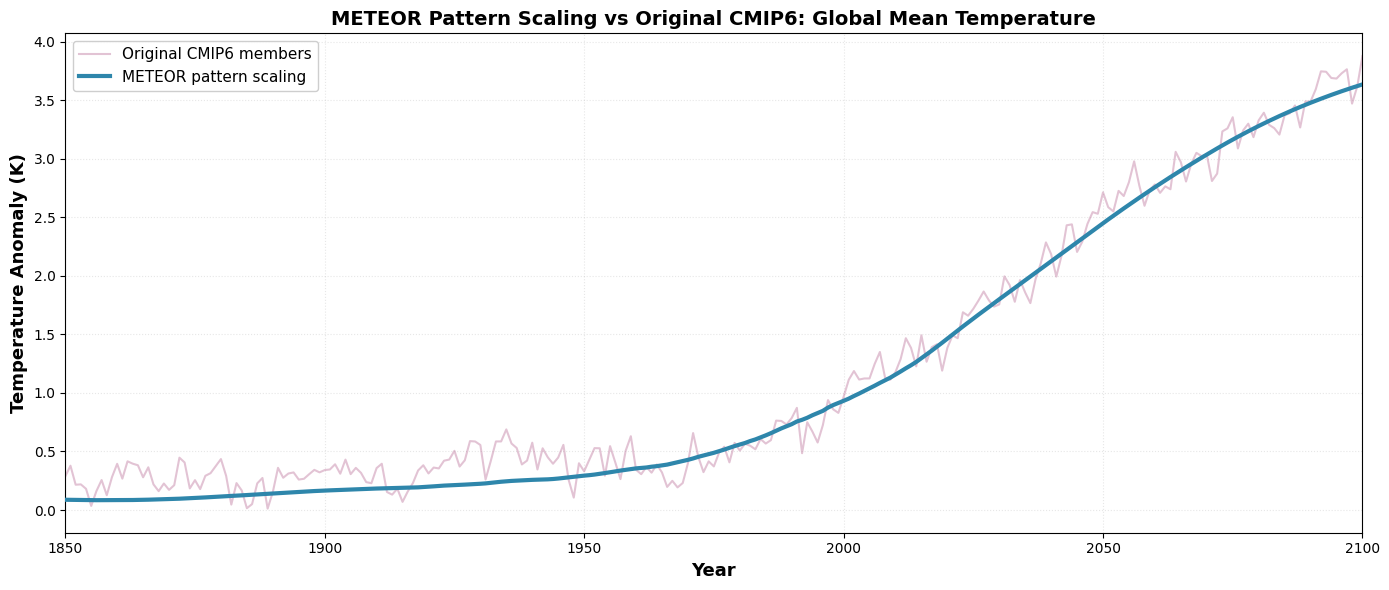


✅ Comparison plot created
   METEOR prediction: 351 years
   Original CMIP6: 251 years
   CMIP6 ensemble members: 1

💡 The METEOR pattern scaling captures the forced response
   without the internal variability present in individual CMIP6 members.


In [10]:
# Compare METEOR pattern scaling prediction with original CMIP6 annual data
print("\n📊 Comparing METEOR pattern scaling with original CMIP6 data...")

# Get METEOR prediction (annual, already calculated)
meteor_prediction_global = prpatt.global_mean(temperature_prediction).values

# Create time axes
years_original = np.arange(1850, 1850 + len(original_ssp245_annual_mean.values[0]))
years_meteor = np.arange(0, len(meteor_prediction_global))+1750  # Starts at year 0

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original CMIP6 ensemble members
for i in range(ssp245_annual.shape[0]):
    ax.plot(years_original, original_ssp245_annual_mean.values[i], 
            color='#A23B72', alpha=0.3, linewidth=1.5, 
            label='Original CMIP6 members' if i == 0 else '')

# Plot METEOR prediction
ax.plot(years_meteor, meteor_prediction_global, 
        color='#2E86AB', linewidth=3, label='METEOR pattern scaling', 
        linestyle='-', zorder=10)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('METEOR Pattern Scaling vs Original CMIP6: Global Mean Temperature', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.show()

print(f"\n✅ Comparison plot created")
print(f"   METEOR prediction: {len(meteor_prediction_global)} years")
print(f"   Original CMIP6: {len(original_ssp245_annual_mean.values[0])} years")
print(f"   CMIP6 ensemble members: {ssp245_annual.shape[0]}")
print("\n💡 The METEOR pattern scaling captures the forced response")
print("   without the internal variability present in individual CMIP6 members.")

## 7. Train Noise Model and Generate IC Ensemble

In [11]:
# Train noise model from CMIP6 data
from meteor.noise_generator import train_noise_model_from_cmip6, MeteorNoiseGenerator
from meteor import prpatt

# Get variable name from data_getter
variable_name = data_getter.flds[0]

# Get cache path using data getter helper
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")
noise_cache_file = data_getter.get_noise_model_cache_path(
    model_name, variable_name, noise_cache_dir
)

# Validate cache using data getter method
is_valid, tas_noise_model, info = data_getter.validate_noise_model_cache(
    noise_cache_file, variable_name, n_modes=40, lag_order=2
)

if is_valid:
    print(f"✅ {info['message']}")
    
    # Still need monthly_prediction and monthly_warming for ensemble generation
    print("   Preparing monthly prediction data...")
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    print(f"✅ Noise model loaded from cache")
else:
    print(f"⚠️  {info['message']}")
    print(f"🔧 Training new noise model for variable '{variable_name}'...")
    
    # Convert annual predictions to monthly
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    # Skip first 100 years (spin-up)
    monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months
    
    # Train the noise model
    tas_noise_model = train_noise_model_from_cmip6(
        data_getter,
        experiments=["historical", "ssp245"],
        model_name=model_name,
        variable_name=variable_name,
        n_modes=40,  # Number of PCA modes
        lag_order=2,  # Temporal lag
        custom_global_temp=monthly_warming_trimmed,
        use_picontrol_baseline=True,
        cache_dir=noise_cache_dir,
        use_exog='all'
    )
    
    print(f"✅ Noise model trained successfully for '{variable_name}'")
    print(f"   Training length: {len(monthly_warming_trimmed)//12} years")


Model loaded from /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
✅ Cache valid: variable=tas, n_modes=40, lag_order=2
   Preparing monthly prediction data...
✅ Noise model loaded from cache
✅ Noise model loaded from cache


In [12]:
monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months


### Comprehensive Demonstration: Global, Regional, and Point-Scale

Create a 3-panel figure showing 100-member ensembles at different spatial scales.

In [13]:
# Generate ensemble for demonstration
# Use 100 members for global/regional, 1000 members for Oslo point analysis

n_demo = 100  # For global and regional means
n_oslo = 1000  # For Oslo point-scale (better statistics for degree days)

start = time.time()

# Generate stochastic PCs for global/regional analysis
demo_pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_demo,
    random_seed=123
)
print(f"✅ Generated {n_demo} stochastic PCs for global/regional")

# Generate additional stochastic PCs for Oslo
oslo_pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_oslo,
    random_seed=456
)
print(f"✅ Generated {n_oslo} stochastic PCs for Oslo point analysis")


✅ Generated 100 stochastic PCs for global/regional
✅ Generated 1000 stochastic PCs for Oslo point analysis
✅ Generated 1000 stochastic PCs for Oslo point analysis


In [14]:
# Load original CESM2 SSP245 data for comparison
print("📥 Loading original CESM2 SSP245 monthly data from cache...")

ssp245_data = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=True
)["tas"]

pictrl_data = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=True
)["tas"]

# Calculate global mean for the original SSP245 data
original_pictrl_global_mean = calculate_global_mean(pictrl_data)
original_global_mean = calculate_global_mean(ssp245_data) - np.mean(original_pictrl_global_mean)

# Calculate regional means for NEU (Northern Europe)
original_regional_mean = calculate_regional_mean(ssp245_data, "NEU")
original_pictrl_regional_mean = calculate_regional_mean(pictrl_data, "NEU")

print(f"✅ Original CESM2 data loaded")
print(f"   SSP245 shape: {ssp245_data.shape}")
print(f"   piControl shape: {pictrl_data.shape}")
print(f"   Global mean calculated")
print(f"   NEU regional mean calculated: {original_regional_mean.attrs['region_name']}")



INFO: Loading data from cache: CESM2_historical_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/historical/tas
INFO: Loading data from cache: CESM2_ssp245_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/ssp245/tas
INFO: ✓ Using cached monthly data for CESM2/ssp245/tas


📥 Loading original CESM2 SSP245 monthly data from cache...


INFO: Loading data from cache: CESM2_piControl_tas_monthly.nc
INFO: ✓ Using cached monthly data for CESM2/piControl/tas
INFO: ✓ Using cached monthly data for CESM2/piControl/tas


✅ Original CESM2 data loaded
   SSP245 shape: (1, 3012, 192, 288)
   piControl shape: (1, 600, 192, 288)
   Global mean calculated
   NEU regional mean calculated: N.Europe


In [15]:
monthly_prediction_global_mean = prpatt.global_mean(monthly_prediction)
monthly_prediction_neu_mean = calculate_regional_mean(monthly_prediction, "NEU")

In [16]:

# 1. Global mean ensemble
demo_global = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_global_mean
)
print(f"✅ Global mean: {demo_global.shape}")

# 2. Regional mean ensemble (NEU - Northern Europe)
demo_neu = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='NEU',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_neu_mean
)
print(f"✅ NEU regional mean: {demo_neu.shape}")

# 3. Point-scale ensemble (Oslo: 59.9°N, 10.8°E) - using larger ensemble
oslo_lat, oslo_lon = 59.9, 10.8
lat_idx, lon_idx = tas_noise_model._find_nearest_gridpoint(oslo_lat, oslo_lon)
oslo_base = monthly_prediction[:, lat_idx, lon_idx]
original_oslo_anomaly_values = ssp245_data[:, :, lat_idx, lon_idx] - np.mean(pictrl_data[:, :, lat_idx, lon_idx])

demo_oslo = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    lat=oslo_lat,
    lon=oslo_lon,
    stochastic_pcs=oslo_pcs,  # Use larger ensemble for Oslo
    noise_only=True,
    add_base=oslo_base
)
print(f"✅ Oslo point: {demo_oslo.shape}")

elapsed_demo = time.time() - start
print(f"\n⏱️  Total generation time: {elapsed_demo:.2f}s")
print(f"   Global/Regional: {elapsed_demo/(n_demo):.3f}s per realization × 2 locations")
print(f"   Oslo: {elapsed_demo/(n_oslo):.4f}s per realization × 1 location")
print("="*70)

✅ Global mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ Oslo point: (1000, 4212)

⏱️  Total generation time: 72.17s
   Global/Regional: 0.722s per realization × 2 locations
   Oslo: 0.0722s per realization × 1 location
✅ Oslo point: (1000, 4212)

⏱️  Total generation time: 72.17s
   Global/Regional: 0.722s per realization × 2 locations
   Oslo: 0.0722s per realization × 1 location


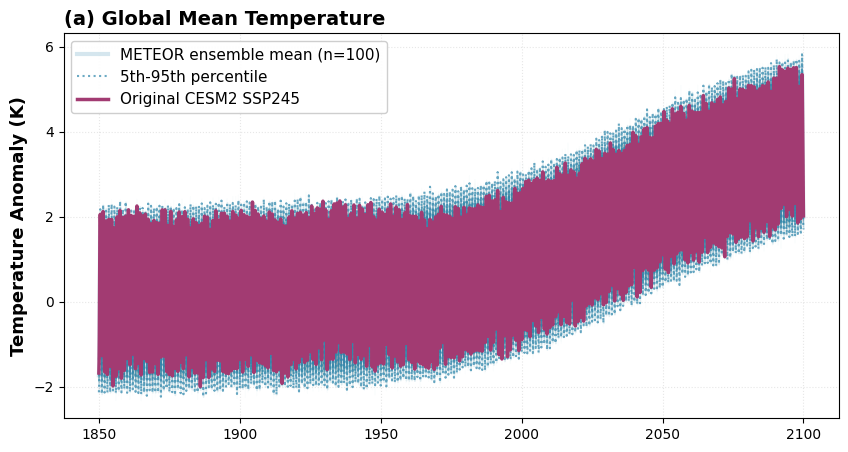

In [17]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 1850, 2100

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10,alpha=0.2)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='-',
        label=f'Original {model_name} SSP245', zorder=10, marker='', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)


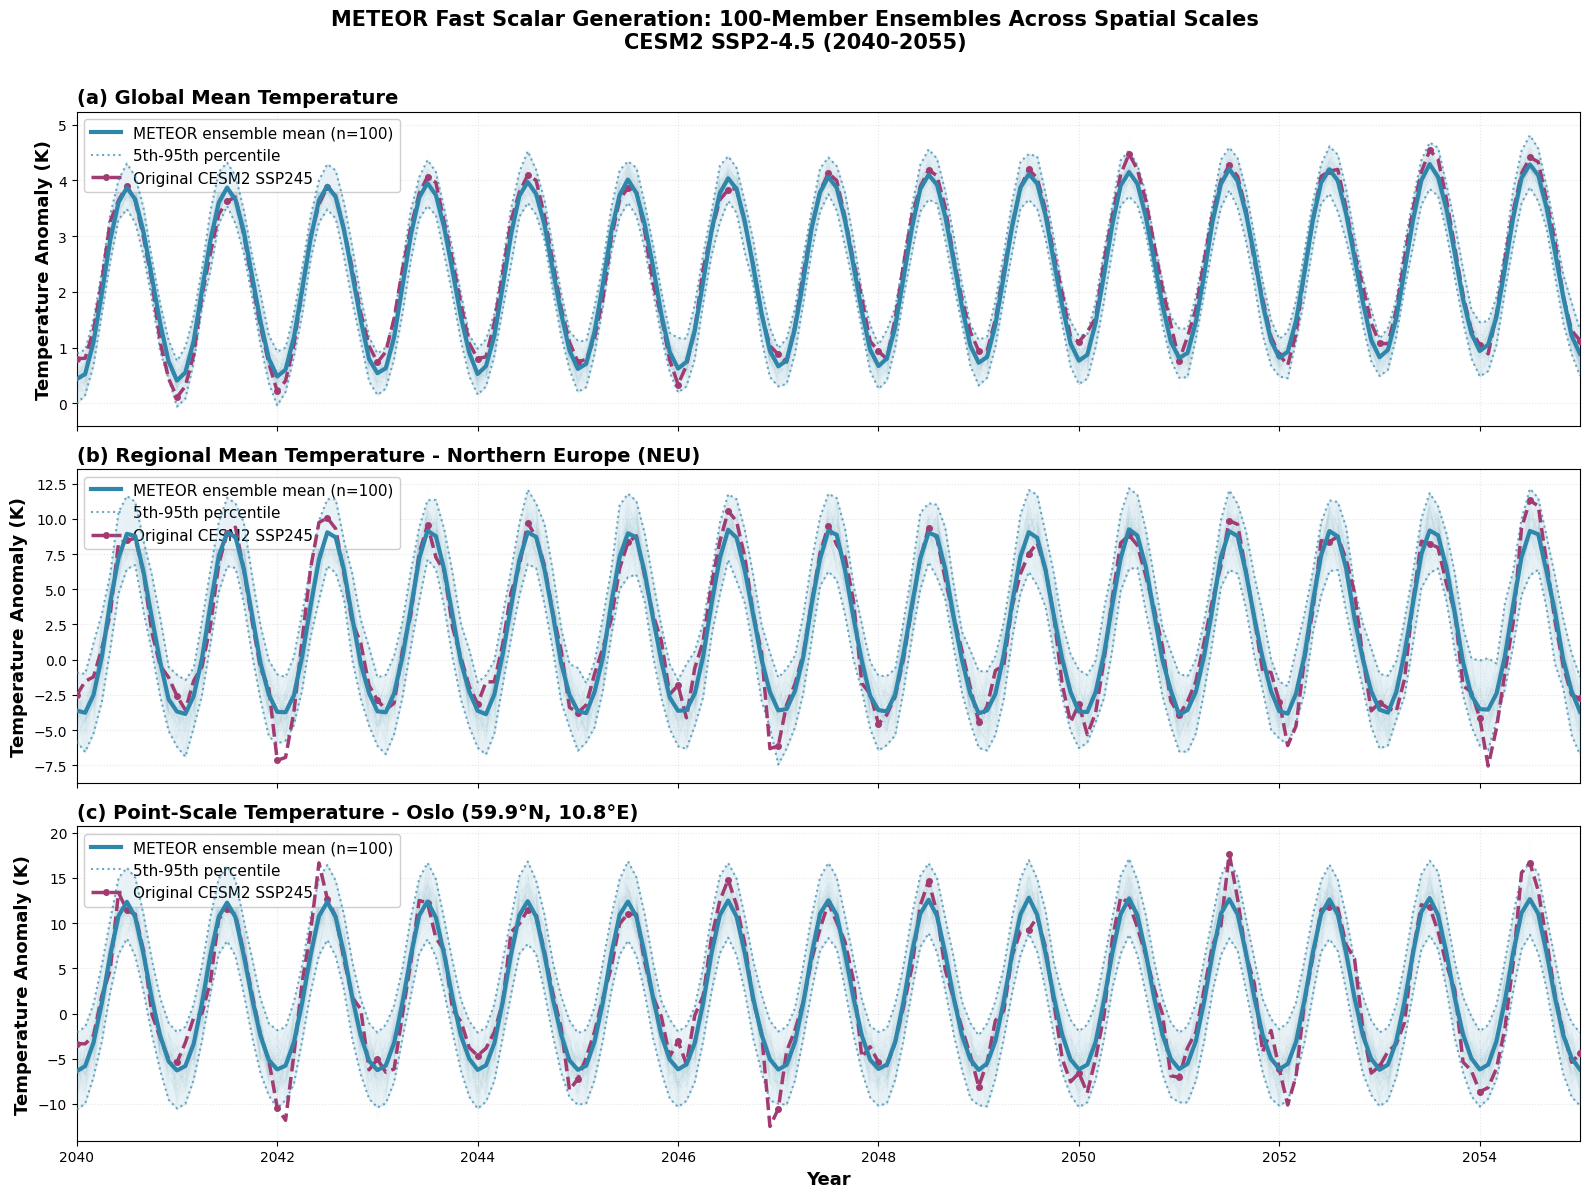


✅ Created comprehensive 3-panel demonstration figure
   Showing global, regional (NEU), and point-scale (Oslo) ensembles
   Period: 2040-2055
   Ensemble size: 100 members
   All scales share identical stochastic variability!


In [18]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 2040, 2055

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes[0]

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 2: REGIONAL MEAN (Northern Europe)
# ============================================================================
ax = axes[1]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_neu.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_neu = demo_neu.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_neu[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_neu = demo_neu.quantile(0.01, dim='realization').values[offset:]
perc_95_neu = demo_neu.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_neu[time_mask_offset], perc_95_neu[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
original_neu_anomaly = original_regional_mean - original_pictrl_regional_mean.mean()
ax.plot(time_plot, original_neu_anomaly.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title(f'(b) Regional Mean Temperature - Northern Europe (NEU)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 3: POINT-SCALE (Oslo)
# ============================================================================
ax = axes[2]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_oslo.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_oslo = demo_oslo.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_oslo = demo_oslo.quantile(0.01, dim='realization').values[offset:]
perc_95_oslo = demo_oslo.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_oslo[time_mask_offset], perc_95_oslo[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_oslo_anomaly_values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_title(f'(c) Point-Scale Temperature - Oslo ({oslo_lat}°N, {oslo_lon}°E)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# Set x-axis limits
for ax in axes:
    ax.set_xlim(zoom_start, zoom_end)

# Overall title
fig.suptitle(f'METEOR Fast Scalar Generation: {n_demo}-Member Ensembles Across Spatial Scales\n{model_name} SSP2-4.5 ({zoom_start}-{zoom_end})', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"\n✅ Created comprehensive 3-panel demonstration figure")
print(f"   Showing global, regional (NEU), and point-scale (Oslo) ensembles")
print(f"   Period: {zoom_start}-{zoom_end}")
print(f"   Ensemble size: {n_demo} members")
print(f"   All scales share identical stochastic variability!")


### Ensemble Adequacy Testing

Test whether the original CMIP6 simulations fall within the METEOR ensemble distribution as expected. If the ensemble is well-calibrated, the original data should be uniformly distributed across the ensemble percentiles.

In [19]:
def calculate_ensemble_rank(observation, ensemble):
    """
    Calculate the rank of an observation within an ensemble distribution.
    
    Parameters
    ----------
    observation : array-like
        Observed values (time series)
    ensemble : array-like
        Ensemble members (n_members x time)
        
    Returns
    -------
    ranks : array
        Rank percentiles (0-1) for each timestep
    """
    n_members = ensemble.shape[0]
    ranks = np.zeros(len(observation))
    
    for t in range(len(observation)):
        # Count how many ensemble members are below the observation
        count_below = np.sum(ensemble[:, t] < observation[t])
        # Rank as percentile (0 to 1)
        ranks[t] = count_below / n_members
    
    return ranks


# Calculate ranks for each region across the overlapping time period
print("🔍 Calculating ensemble ranks for original CMIP6 data...")
print("="*70)

# Use the time period where we have both METEOR and original data (after offset)
analysis_start_idx = offset  # Start after the offset
analysis_length = min(len(original_global_mean.values[0]), 
                      len(demo_global.values[0]) - offset)

# 1. Global mean ranks (first CMIP6 ensemble member)
global_obs = original_global_mean.values[0, :analysis_length]
global_ens = demo_global.values[:, offset:offset+analysis_length]
global_ranks = calculate_ensemble_rank(global_obs, global_ens)

print(f"✅ Global mean ranks calculated: {len(global_ranks)} timesteps")
print(f"   Mean rank: {np.mean(global_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(global_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 2. Regional mean ranks (NEU - first CMIP6 ensemble member)
neu_obs = original_neu_anomaly.values[0, :analysis_length]
neu_ens = demo_neu.values[:, offset:offset+analysis_length]
neu_ranks = calculate_ensemble_rank(neu_obs, neu_ens)

print(f"✅ NEU regional ranks calculated: {len(neu_ranks)} timesteps")
print(f"   Mean rank: {np.mean(neu_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(neu_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 3. Point-scale ranks (Oslo - first CMIP6 ensemble member)
# Convert to numpy array if it's an xarray DataArray
if hasattr(original_oslo_anomaly_values, 'values'):
    oslo_obs = original_oslo_anomaly_values.values[0, :analysis_length]
else:
    oslo_obs = original_oslo_anomaly_values[0, :analysis_length]
oslo_ens = demo_oslo.values[:, offset:offset+analysis_length]
oslo_ranks = calculate_ensemble_rank(oslo_obs, oslo_ens)

print(f"✅ Oslo point ranks calculated: {len(oslo_ranks)} timesteps")
print(f"   Mean rank: {np.mean(oslo_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(oslo_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

print("="*70)
print("\n💡 For a well-calibrated ensemble:")
print("   - Ranks should be uniformly distributed between 0 and 1")
print("   - Mean rank ≈ 0.5")
print(f"   - Std rank ≈ {1/np.sqrt(12):.3f} (1/√12 for uniform distribution)")

🔍 Calculating ensemble ranks for original CMIP6 data...
✅ Global mean ranks calculated: 3012 timesteps
   Mean rank: 0.615 (expected: 0.5)
   Std rank: 0.275 (expected: 0.289)
✅ NEU regional ranks calculated: 3012 timesteps
   Mean rank: 0.498 (expected: 0.5)
   Std rank: 0.274 (expected: 0.289)
✅ Oslo point ranks calculated: 3012 timesteps
   Mean rank: 0.516 (expected: 0.5)
   Std rank: 0.286 (expected: 0.289)

💡 For a well-calibrated ensemble:
   - Ranks should be uniformly distributed between 0 and 1
   - Mean rank ≈ 0.5
   - Std rank ≈ 0.289 (1/√12 for uniform distribution)


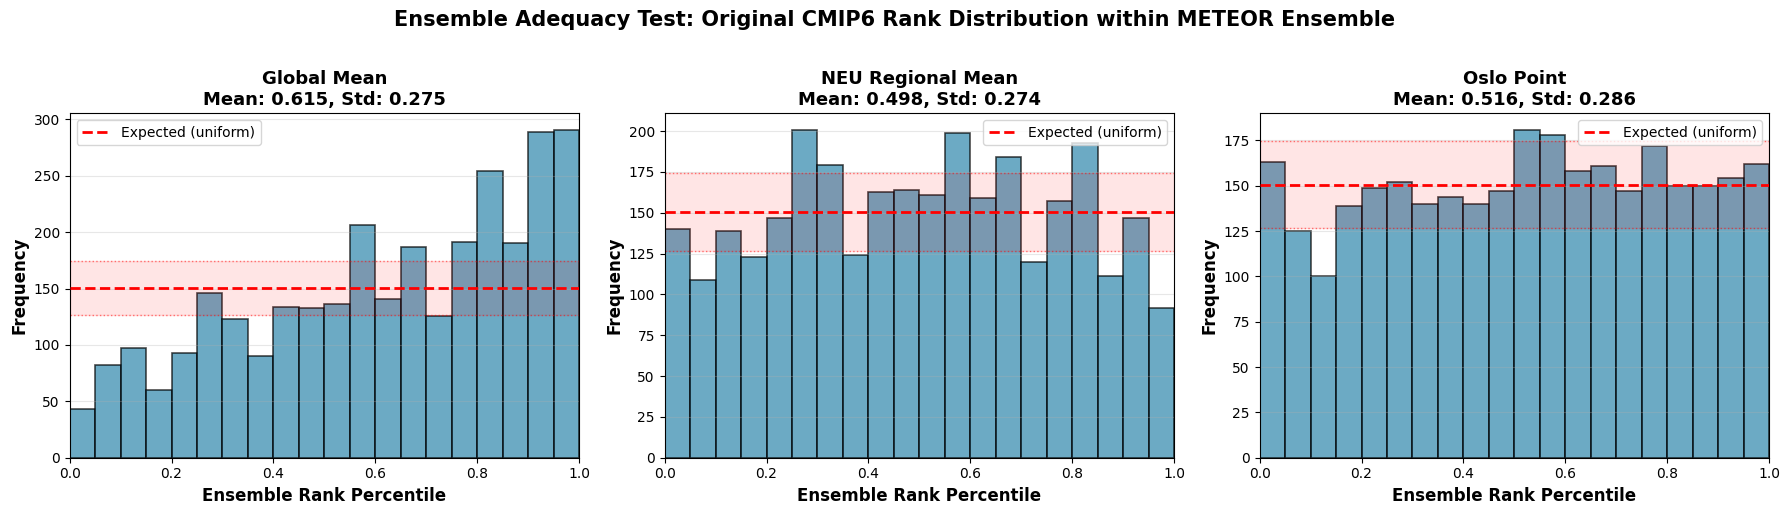


📊 Histogram Analysis:
   If the ensemble is well-calibrated, histograms should be approximately flat
   (uniform distribution across all percentile bins)
   Number of timesteps analyzed: 3012
   Expected count per bin: 150.6
   95% confidence interval: [126.7, 174.5]


In [20]:
# Create histograms showing rank distributions for all three regions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
expected_count = len(global_ranks) / 20  # Expected count per bin for uniform distribution

regions = [
    ('Global Mean', global_ranks, axes[0]),
    ('NEU Regional Mean', neu_ranks, axes[1]),
    ('Oslo Point', oslo_ranks, axes[2])
]

for region_name, ranks, ax in regions:
    # Plot histogram
    counts, edges, patches = ax.hist(ranks, bins=bins, alpha=0.7, color='#2E86AB', 
                                      edgecolor='black', linewidth=1.2)
    
    # Plot expected uniform distribution line
    ax.axhline(expected_count, color='red', linestyle='--', linewidth=2, 
               label=f'Expected (uniform)', zorder=10)
    
    # Add shaded confidence interval for uniform distribution (±2σ)
    # For binomial: σ = sqrt(n*p*(1-p)) where p=1/20, n=total_timesteps
    p = 1/20
    sigma = np.sqrt(len(ranks) * p * (1-p))
    ax.axhline(expected_count + 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(expected_count - 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.fill_between([0, 1], expected_count - 2*sigma, expected_count + 2*sigma,
                     color='red', alpha=0.1, zorder=1)
    
    # Labels and formatting
    ax.set_xlabel('Ensemble Rank Percentile', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{region_name}\nMean: {np.mean(ranks):.3f}, Std: {np.std(ranks):.3f}', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)

plt.suptitle('Ensemble Adequacy Test: Original CMIP6 Rank Distribution within METEOR Ensemble', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Histogram Analysis:")
print("   If the ensemble is well-calibrated, histograms should be approximately flat")
print("   (uniform distribution across all percentile bins)")
print(f"   Number of timesteps analyzed: {len(global_ranks)}")
print(f"   Expected count per bin: {expected_count:.1f}")
print(f"   95% confidence interval: [{expected_count - 2*sigma:.1f}, {expected_count + 2*sigma:.1f}]")

## 8. Calculate Heating and Cooling Degree Days for Oslo

Now we'll use the Oslo ensemble temperatures to calculate heating and cooling degree days

In [21]:
# Import the degree days calculator
from meteor.impacts import DegreeDaysCalculator

# Set base temperature for degree days calculation (18°C is standard for residential)
BASE_TEMPERATURE = 18.0

# Initialize the calculator
dd_calculator = DegreeDaysCalculator(base_temperature=BASE_TEMPERATURE)

print(f"🔧 Degree Days Calculator initialized")
print(f"   Base temperature: {BASE_TEMPERATURE}°C")
print(f"   Method: Isaac and van Vuuren (2009)")

# Calculate degree days for each ensemble member
# IMPORTANT: demo_oslo contains temperature ANOMALIES (not absolute temperatures)
# We need to add the piControl baseline to get absolute temperatures

# Get the piControl baseline for Oslo
oslo_picontrol_baseline = pictrl_data[:, :, lat_idx, lon_idx].mean()  # Mean over all piControl data
print(f"📊 Oslo piControl baseline: {oslo_picontrol_baseline.values:.2f} K ({oslo_picontrol_baseline.values - 273.15:.2f}°C)")

oslo_dd_results = []

print(f"🔄 Calculating degree days for {n_oslo} ensemble members...")

for i in range(n_oslo):
    # Get this ensemble member's temperature anomaly
    # demo_oslo has dimensions (realization, month)
    oslo_temp_anomaly = demo_oslo.isel(realization=i)
    
    # Add piControl baseline to get absolute temperature in Kelvin
    oslo_temp_kelvin = oslo_temp_anomaly + oslo_picontrol_baseline
    
    # Convert to Celsius for degree days calculation
    oslo_temp_celsius = oslo_temp_kelvin - 273.15 
    
    # Calculate degree days
    dd_result = dd_calculator.calculate(oslo_temp_celsius)
    oslo_dd_results.append(dd_result)
    
    # Progress update every 100 members
    if (i + 1) % 100 == 0:
        print(f"   Processed {i + 1}/{n_oslo} members...")

print(f"✅ Degree days calculated for {len(oslo_dd_results)} ensemble members")
print(f"   Available metrics: {list(oslo_dd_results[0].keys())}")

# Calculate degree days for original CESM2 data
print(f"\n🔄 Calculating degree days for original CESM2 ensemble members...")
oslo_dd_original = []

for i in range(ssp245_data.shape[0]):
    # Get absolute temperature (not anomaly) for this CESM2 ensemble member
    oslo_temp_original = ssp245_data[i, :, lat_idx, lon_idx]
    
    # Convert to Celsius for degree days calculation
    oslo_temp_celsius_original = oslo_temp_original - 273.15
    
    # Calculate degree days
    dd_result_original = dd_calculator.calculate(oslo_temp_celsius_original)
    oslo_dd_original.append(dd_result_original)

print(f"✅ Degree days calculated for {len(oslo_dd_original)} original CESM2 members")


🔧 Degree Days Calculator initialized
   Base temperature: 18.0°C
   Method: Isaac and van Vuuren (2009)
📊 Oslo piControl baseline: 278.16 K (5.01°C)
🔄 Calculating degree days for 1000 ensemble members...
   Processed 100/1000 members...
   Processed 100/1000 members...
   Processed 200/1000 members...
   Processed 200/1000 members...
   Processed 300/1000 members...
   Processed 300/1000 members...
   Processed 400/1000 members...
   Processed 400/1000 members...
   Processed 500/1000 members...
   Processed 500/1000 members...
   Processed 600/1000 members...
   Processed 600/1000 members...
   Processed 700/1000 members...
   Processed 700/1000 members...
   Processed 800/1000 members...
   Processed 800/1000 members...
   Processed 900/1000 members...
   Processed 900/1000 members...
   Processed 1000/1000 members...
✅ Degree days calculated for 1000 ensemble members
   Available metrics: ['monthly_hdd', 'monthly_cdd', 'annual_hdd', 'annual_cdd']

🔄 Calculating degree days for origi

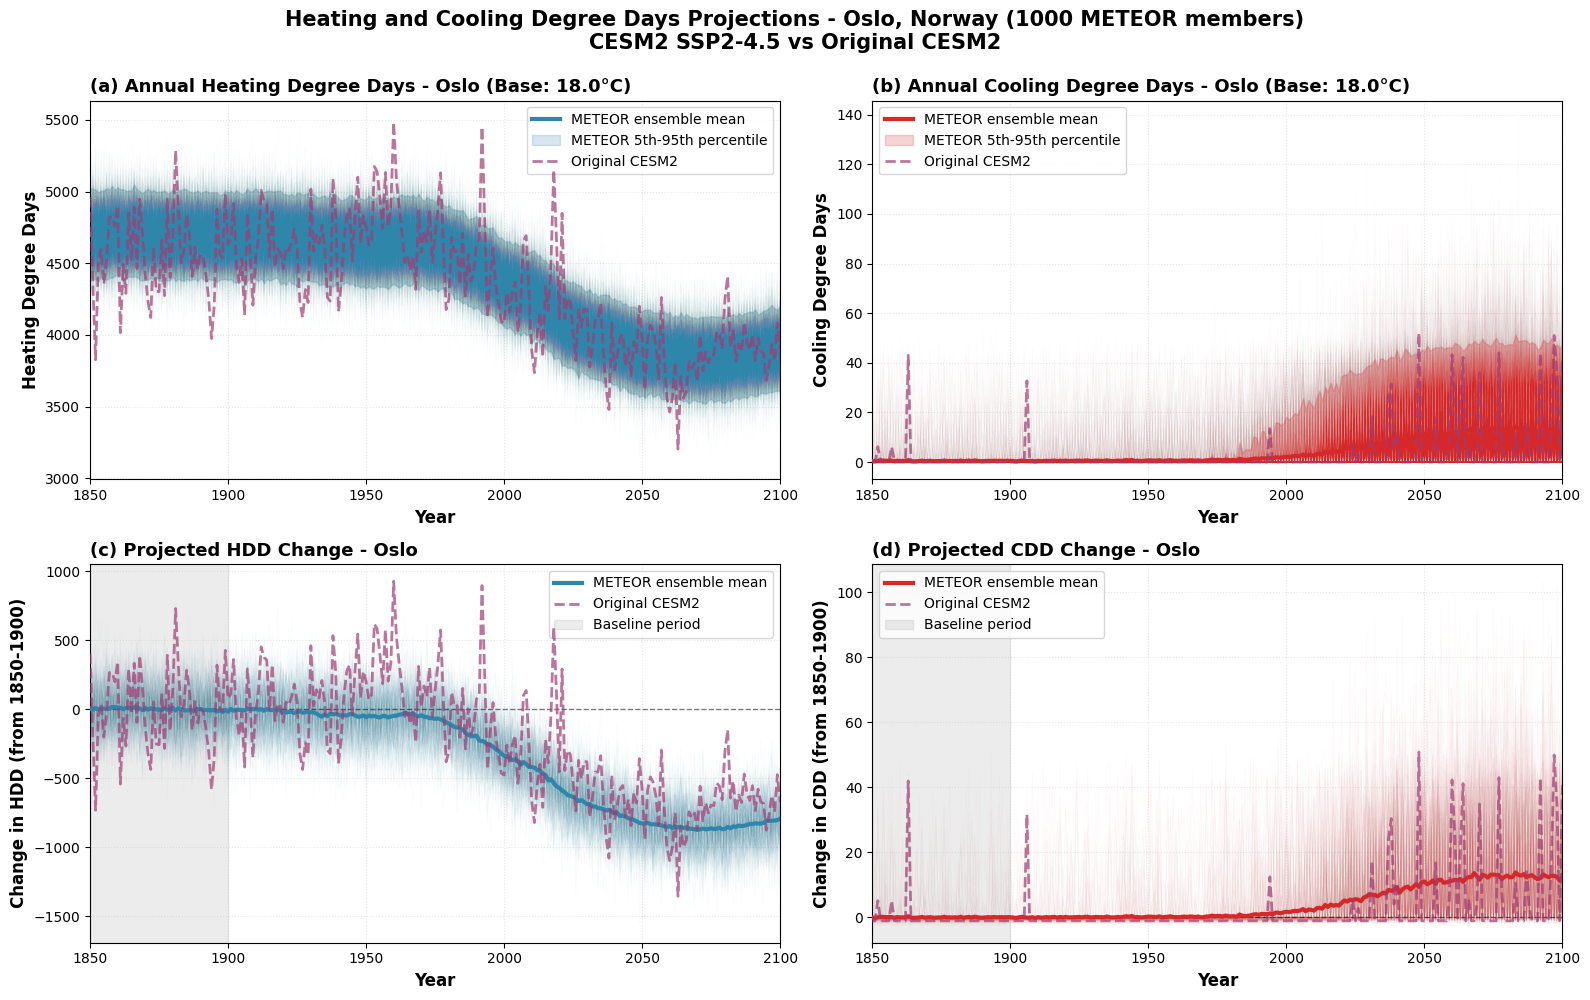


📊 Oslo Degree Days Summary
   Baseline period: 1850-1900
   
   METEOR Ensemble (1000 members):
   Heating Degree Days (HDD):
      Baseline (1850-1900): 4696 ± 26 degree-days
      Year 2100: 3904 ± 180 degree-days
      Change: -792 degree-days (-16.9%)
   
   Cooling Degree Days (CDD):
      Baseline (1850-1900): 0 ± 1 degree-days
      Year 2100: 13 ± 18 degree-days
      Change: 12 degree-days (2512.7%)
   
   Original CESM2 (1 members):
   Heating Degree Days (HDD):
      Baseline (1850-1900): 4557 degree-days
      Year 2100: 3886 degree-days
      Change: -671 degree-days (-14.7%)
   
   Cooling Degree Days (CDD):
      Baseline (1850-1900): 1 degree-days
      Year 2100: 42 degree-days
      Change: 41 degree-days (3793.4%)
   
   💡 Decreasing HDD indicates reduced heating demand
      Increasing CDD indicates increased cooling demand


In [22]:
# Visualize heating and cooling degree days for Oslo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time axis for plotting (annual degree days)
# The degree days start at year 0 (corresponding to 1750), so we add 1750
years_dd = np.arange(len(oslo_dd_results[0]['annual_hdd'])) + 1750

# Extract annual HDD and CDD from all ensemble members
annual_hdd_ensemble = np.array([dd['annual_hdd'].values for dd in oslo_dd_results])
annual_cdd_ensemble = np.array([dd['annual_cdd'].values for dd in oslo_dd_results])

# Extract annual HDD and CDD from original CESM2 data
# Original data starts at 1850 (year index 100 in the full timeline)
years_dd_original = ssp245_data['month'].values / 12 + 1850
years_dd_original_annual = np.arange(1850, 1850 + len(oslo_dd_original[0]['annual_hdd']))

annual_hdd_original = np.array([dd['annual_hdd'].values for dd in oslo_dd_original])
annual_cdd_original = np.array([dd['annual_cdd'].values for dd in oslo_dd_original])

# Colors
hdd_color = '#2E86AB'  # Blue for heating
cdd_color = '#D62828'  # Red for cooling
original_color = '#A23B72'  # Purple/magenta for original CESM2

# ============================================================================
# Panel 1: Annual Heating Degree Days (Full Period)
# ============================================================================
ax = axes[0, 0]

# Plot individual ensemble members (with lower alpha for 1000 members)
for i in range(n_oslo):
    ax.plot(years_dd, annual_hdd_ensemble[i], 
            color=hdd_color, alpha=0.01, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_hdd = annual_hdd_ensemble.mean(axis=0)
ax.plot(years_dd, ensemble_mean_hdd, 
        color=hdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Plot percentiles
perc_05_hdd = np.percentile(annual_hdd_ensemble, 5, axis=0)
perc_95_hdd = np.percentile(annual_hdd_ensemble, 95, axis=0)
ax.fill_between(years_dd, perc_05_hdd, perc_95_hdd, 
                color=hdd_color, alpha=0.2, label='METEOR 5th-95th percentile')

# Overlay original CESM2 data
for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, annual_hdd_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Heating Degree Days', fontsize=12, fontweight='bold')
ax.set_title(f'(a) Annual Heating Degree Days - Oslo (Base: {BASE_TEMPERATURE}°C)', 
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(1850, 2100)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper right')

# ============================================================================
# Panel 2: Annual Cooling Degree Days (Full Period)
# ============================================================================
ax = axes[0, 1]

# Plot individual ensemble members
for i in range(n_oslo):
    ax.plot(years_dd, annual_cdd_ensemble[i], 
            color=cdd_color, alpha=0.01, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_cdd = annual_cdd_ensemble.mean(axis=0)
ax.plot(years_dd, ensemble_mean_cdd, 
        color=cdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Plot percentiles
perc_05_cdd = np.percentile(annual_cdd_ensemble, 5, axis=0)
perc_95_cdd = np.percentile(annual_cdd_ensemble, 95, axis=0)
ax.fill_between(years_dd, perc_05_cdd, perc_95_cdd, 
                color=cdd_color, alpha=0.2, label='METEOR 5th-95th percentile')

# Overlay original CESM2 data
for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, annual_cdd_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cooling Degree Days', fontsize=12, fontweight='bold')
ax.set_title(f'(b) Annual Cooling Degree Days - Oslo (Base: {BASE_TEMPERATURE}°C)', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1850, 2100)


# ============================================================================
# Panel 3: HDD Change (Full period with baseline as reference)
# ============================================================================
ax = axes[1, 0]

# Calculate baseline (1850-1900) for reference
baseline_mask = (years_dd >= 1850) & (years_dd <= 1900)
baseline_hdd = annual_hdd_ensemble[:, baseline_mask].mean(axis=1)  # Mean per member

# Calculate change for all years relative to each member's baseline
hdd_change_full = annual_hdd_ensemble - baseline_hdd[:, np.newaxis]

# Plot ensemble spread (subsample for visibility)
plot_sample = min(200, n_oslo)  # Plot max 200 members for visibility
plot_indices = np.linspace(0, n_oslo-1, plot_sample, dtype=int)

for i in plot_indices:
    ax.plot(years_dd, hdd_change_full[i], 
            color=hdd_color, alpha=0.02, linewidth=0.6)

# Plot ensemble mean change
mean_hdd_change_full = hdd_change_full.mean(axis=0)
ax.plot(years_dd, mean_hdd_change_full, 
        color=hdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Calculate and plot original CESM2 change
baseline_mask_original = (years_dd_original_annual >= 1850) & (years_dd_original_annual <= 1900)
baseline_hdd_original = annual_hdd_original[:, baseline_mask_original].mean(axis=1)
hdd_change_original = annual_hdd_original - baseline_hdd_original[:, np.newaxis]

for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, hdd_change_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

# Add zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add shaded region for baseline period
ax.axvspan(1850, 1900, alpha=0.15, color='gray', label='Baseline period')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in HDD (from 1850-1900)', fontsize=12, fontweight='bold')
ax.set_title('(c) Projected HDD Change - Oslo', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(1850, 2100)

# ============================================================================
# Panel 4: CDD Change (Full period with baseline as reference)
# ============================================================================
ax = axes[1, 1]

# Calculate CDD change for all years
baseline_cdd = annual_cdd_ensemble[:, baseline_mask].mean(axis=1)
cdd_change_full = annual_cdd_ensemble - baseline_cdd[:, np.newaxis]

# Plot ensemble spread (subsample for visibility)
for i in plot_indices:
    ax.plot(years_dd, cdd_change_full[i], 
            color=cdd_color, alpha=0.02, linewidth=0.6)

# Plot ensemble mean change
mean_cdd_change_full = cdd_change_full.mean(axis=0)
ax.plot(years_dd, mean_cdd_change_full, 
        color=cdd_color, linewidth=3, label='METEOR ensemble mean', zorder=10)

# Calculate and plot original CESM2 change
baseline_cdd_original = annual_cdd_original[:, baseline_mask_original].mean(axis=1)
cdd_change_original = annual_cdd_original - baseline_cdd_original[:, np.newaxis]

for i in range(len(oslo_dd_original)):
    ax.plot(years_dd_original_annual, cdd_change_original[i], 
            color=original_color, linewidth=2, linestyle='--', alpha=0.7,
            label='Original CESM2' if i == 0 else '', zorder=11)

# Add zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add shaded region for baseline period
ax.axvspan(1850, 1900, alpha=0.15, color='gray', label='Baseline period')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in CDD (from 1850-1900)', fontsize=12, fontweight='bold')
ax.set_title('(d) Projected CDD Change - Oslo', 
             fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1850, 2100)

plt.suptitle(f'Heating and Cooling Degree Days Projections - Oslo, Norway ({n_oslo} METEOR members)\n{model_name} SSP2-4.5 vs Original CESM2', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
baseline_hdd_mean = baseline_hdd.mean()
baseline_hdd_std = baseline_hdd.std()
future_2100_hdd_mean = annual_hdd_ensemble[:, years_dd == 2100].mean()
future_2100_hdd_std = annual_hdd_ensemble[:, years_dd == 2100].std()

baseline_cdd_mean = baseline_cdd.mean()
baseline_cdd_std = baseline_cdd.std()
future_2100_cdd_mean = annual_cdd_ensemble[:, years_dd == 2100].mean()
future_2100_cdd_std = annual_cdd_ensemble[:, years_dd == 2100].std()

# Original CESM2 statistics
baseline_hdd_original_mean = baseline_hdd_original.mean()
baseline_cdd_original_mean = baseline_cdd_original.mean()
future_2100_hdd_original_mean = annual_hdd_original[:, years_dd_original_annual == 2100].mean()
future_2100_cdd_original_mean = annual_cdd_original[:, years_dd_original_annual == 2100].mean()

print(f"\n📊 Oslo Degree Days Summary")
print("="*70)
print(f"   Baseline period: 1850-1900")
print(f"   ")
print(f"   METEOR Ensemble ({n_oslo} members):")
print(f"   Heating Degree Days (HDD):")
print(f"      Baseline (1850-1900): {baseline_hdd_mean:.0f} ± {baseline_hdd_std:.0f} degree-days")
print(f"      Year 2100: {future_2100_hdd_mean:.0f} ± {future_2100_hdd_std:.0f} degree-days")
print(f"      Change: {future_2100_hdd_mean - baseline_hdd_mean:.0f} degree-days ({((future_2100_hdd_mean - baseline_hdd_mean)/baseline_hdd_mean*100):.1f}%)")
print(f"   ")
print(f"   Cooling Degree Days (CDD):")
print(f"      Baseline (1850-1900): {baseline_cdd_mean:.0f} ± {baseline_cdd_std:.0f} degree-days")
print(f"      Year 2100: {future_2100_cdd_mean:.0f} ± {future_2100_cdd_std:.0f} degree-days")
print(f"      Change: {future_2100_cdd_mean - baseline_cdd_mean:.0f} degree-days ({((future_2100_cdd_mean - baseline_cdd_mean)/baseline_cdd_mean*100 if baseline_cdd_mean > 0 else float('inf')):.1f}%)")
print(f"   ")
print(f"   Original CESM2 ({len(oslo_dd_original)} members):")
print(f"   Heating Degree Days (HDD):")
print(f"      Baseline (1850-1900): {baseline_hdd_original_mean:.0f} degree-days")
print(f"      Year 2100: {future_2100_hdd_original_mean:.0f} degree-days")
print(f"      Change: {future_2100_hdd_original_mean - baseline_hdd_original_mean:.0f} degree-days ({((future_2100_hdd_original_mean - baseline_hdd_original_mean)/baseline_hdd_original_mean*100):.1f}%)")
print(f"   ")
print(f"   Cooling Degree Days (CDD):")
print(f"      Baseline (1850-1900): {baseline_cdd_original_mean:.0f} degree-days")
print(f"      Year 2100: {future_2100_cdd_original_mean:.0f} degree-days")
print(f"      Change: {future_2100_cdd_original_mean - baseline_cdd_original_mean:.0f} degree-days ({((future_2100_cdd_original_mean - baseline_cdd_original_mean)/baseline_cdd_original_mean*100 if baseline_cdd_original_mean > 0 else float('inf')):.1f}%)")
print(f"   ")
print(f"   💡 Decreasing HDD indicates reduced heating demand")
print(f"      Increasing CDD indicates increased cooling demand")


# Precip test

In [23]:
# Initialize data getter for precipitation
print("📥 Setting up CMIP6 data getter for precipitation...")

pr_data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["pr"],  # Precipitation
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'],
    enable_cache=True
)

print(f"✅ Precipitation data getter initialized")
print(f"   Available models: {pr_data_getter.get_models_avail()}")

INFO: Setting up local cache for CMIP6 data at: /Users/bensan/Documents/Github/METEOR/.cache/cmip6. This will improve performance by storing downloaded data locally.
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv
INFO: Loading CMIP6 catalog from cache: /Users/bensan/Documents/Github/METEOR/.cache/cmip6/cmip6-zarr-consolidated-stores.csv


📥 Setting up CMIP6 data getter for precipitation...
✅ Precipitation data getter initialized
   Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']
✅ Precipitation data getter initialized
   Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 

In [24]:
# Set up precipitation pattern scaling model
pr_model_name = "NorESM2-MM"
pr_scenario = "ssp245"

# Get cache path
pr_cache_dir = os.path.join("..", ".cache", "trained_pattern_scaling_models")
pr_cache_file = pr_data_getter.get_pattern_scaling_cache_path(pr_model_name, pr_cache_dir)

# Validate cache
is_valid_pr, cached_pr_model, pr_info = pr_data_getter.validate_pattern_scaling_cache(
    pr_cache_file, pr_model_name
)

if is_valid_pr:
    print(f"✅ {pr_info['message']}")
    pr_training_data = None
    pr_ssp_config = None
else:
    print(f"⚠️  {pr_info['message']}")
    print(f"🔧 Preparing precipitation training data for {pr_model_name}...")
    
    # Prepare training data
    pr_training_data = pr_data_getter.prepare_pattern_scaling_training_data(
        pr_model_name, pr_scenario
    )
    
    # Detailed NaN diagnostics for precipitation data
    print(f"\n🔍 Detailed NaN Diagnostics for Precipitation Training Data")
    print("="*70)
    
    for exp_name, exp_data in pr_training_data.items():
        if 'pr' in exp_data:
            pr_data = exp_data['pr']
            print(f"\n📊 Experiment: {exp_name}")
            print(f"   Shape: {pr_data.shape}")
            print(f"   Dims: {pr_data.dims}")
            
            # Overall NaN statistics
            nan_mask = np.isnan(pr_data.values)
            total_values = pr_data.size
            nan_count = nan_mask.sum()
            nan_fraction = nan_count / total_values
            
            print(f"   Total NaNs: {nan_count:,} / {total_values:,} ({nan_fraction*100:.2f}%)")
            
            # NaN distribution across dimensions
            if 'time' in pr_data.dims or 'year' in pr_data.dims:
                time_dim = 'time' if 'time' in pr_data.dims else 'year'
                nan_per_time = np.isnan(pr_data.values).sum(axis=tuple(i for i, d in enumerate(pr_data.dims) if d != time_dim))
                print(f"   NaN count range across {time_dim}: {nan_per_time.min():,} - {nan_per_time.max():,}")
                
                # Check if any timestep is fully NaN
                fully_nan_times = np.sum(nan_per_time == pr_data.size / len(pr_data[time_dim]))
                if fully_nan_times > 0:
                    print(f"   ⚠️  {fully_nan_times} timesteps are FULLY NaN!")
            
            # Spatial pattern of NaNs
            if 'lat' in pr_data.dims and 'lon' in pr_data.dims:
                # Sum NaNs across time dimension to see spatial pattern
                time_axis = tuple(i for i, d in enumerate(pr_data.dims) if d not in ['lat', 'lon'])
                nan_spatial = np.isnan(pr_data.values).sum(axis=time_axis) if time_axis else nan_mask
                
                # Count how many grid cells are always NaN
                if time_axis:
                    n_times = np.prod([pr_data.sizes[d] for d in pr_data.dims if d not in ['lat', 'lon']])
                    always_nan = (nan_spatial == n_times).sum()
                    never_nan = (nan_spatial == 0).sum()
                    sometimes_nan = ((nan_spatial > 0) & (nan_spatial < n_times)).sum()
                    
                    print(f"   Grid cells ALWAYS NaN: {always_nan:,} ({always_nan/nan_spatial.size*100:.1f}%)")
                    print(f"   Grid cells NEVER NaN: {never_nan:,} ({never_nan/nan_spatial.size*100:.1f}%)")
                    print(f"   Grid cells SOMETIMES NaN: {sometimes_nan:,} ({sometimes_nan/nan_spatial.size*100:.1f}%)")
            
            # Sample of actual values (non-NaN)
            non_nan_values = pr_data.values[~nan_mask]
            if len(non_nan_values) > 0:
                print(f"   Non-NaN value range: [{non_nan_values.min():.6e}, {non_nan_values.max():.6e}]")
                print(f"   Non-NaN value mean: {non_nan_values.mean():.6e}")
            else:
                print(f"   ⚠️  ALL VALUES ARE NaN!")
    
    print("\n" + "="*70)
    
    # Load SSP configuration
    pr_ssp_config = pr_data_getter.load_ssp_config(pr_scenario)
    print(f"\n✅ Training data prepared")

INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr
INFO: Loading data from cache: NorESM2-MM_abrupt-4xCO2_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr
INFO: Loading data from cache: NorESM2-MM_abrupt-4xCO2_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/abrupt-4xCO2/pr
INFO: Loading data from cache: NorESM2-MM_historical_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/abrupt-4xCO2/pr
INFO: Loading data from cache: NorESM2-MM_historical_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr


⚠️  Cache file not found: ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-aer_pattern_scaling.pkl
🔧 Preparing precipitation training data for NorESM2-MM...
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']

🔍 Detailed NaN Diagnostics for Precipitation Training Data

📊 Experiment: base
   Shape: (1, 150, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   Total NaNs: 0 / 8,294,400 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES NaN: 0 (0.0%)
   Non-NaN value range: [6.388014e-10, 2.354604e-04]
   Non-NaN value mean: 2.700646e-05

📊 Experiment: co2x4
   Shape: (1, 150, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']

🔍 Detailed NaN Diagnostics for Precipitation Training Data

📊 Experiment: base
   Shape:

   Total NaNs: 0 / 8,294,400 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES NaN: 0 (0.0%)
   Non-NaN value range: [4.698869e-12, 3.054185e-04]
   Non-NaN value mean: 2.874021e-05

📊 Experiment: ssp245
   Shape: (1, 251, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   Total NaNs: 0 / 13,879,296 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES NaN: 0 (0.0%)
   Non-NaN value range: [4.765671e-10, 2.625820e-04]
   Non-NaN value mean: 2.726088e-05

📊 Experiment: sulxanom
   Shape: (1, 251, 192, 288)
   Dims: ('ens', 'year', 'lat', 'lon')
   Total NaNs: 0 / 13,879,296 (0.00%)
   NaN count range across year: 0 - 0
   Grid cells ALWAYS NaN: 0 (0.0%)
   Grid cells NEVER NaN: 55,296 (100.0%)
   Grid cells SOMETIMES NaN: 0 (0.0%)
   Non-NaN value range: [4.765671e-10, 2.625820e-04]
   Non-NaN value m

In [25]:
# Create precipitation pattern scaling model
print("🌍 Creating precipitation pattern scaling model...")

pr_pattern_model = MeteorPatternScaling(
    f"cmip6-{pr_model_name}-pr-aer",
    {"pr": 3} if pr_training_data is None else {"pr": 3},  # 3 patterns for precipitation
    None if pr_training_data is None else lambda key: pr_training_data[key],
    ssp_input=pr_ssp_config,
    from_file=False,
    exp_list=None if pr_training_data is None else ["base", "co2x4", "sulxanom"],
    anom_timescales=None if pr_training_data is None else {"pr": 3},
    cache_dir=pr_cache_dir
)

print(f"✅ Precipitation pattern scaling model created: {pr_pattern_model.name}")

# Generate precipitation prediction
print("\n🌧️  Generating precipitation prediction...")
pr_climate_prediction = pr_pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["pr"]
)

pr_prediction = pr_climate_prediction["pr"]
print(f"✅ Precipitation prediction generated")
print(f"   Shape: {pr_prediction.shape}")

🌍 Creating precipitation pattern scaling model...
📦 Loading cached pattern scaling model from ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-pr-aer_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-NorESM2-MM-pr-aer_pattern_scaling.pkl
✅ Precipitation pattern scaling model created: cmip6-NorESM2-MM-pr-aer

🌧️  Generating precipitation prediction...


11
12
113
114
115
22
141
123
142
✅ Precipitation prediction generated
   Shape: (351, 192, 288)
✅ Precipitation prediction generated
   Shape: (351, 192, 288)


In [26]:
# Load original CMIP6 precipitation data for comparison
print("📥 Loading original CMIP6 precipitation data...")

# Get annual precipitation data
pr_ssp245_annual = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=False
)["pr"]

pr_pictrl_annual = pr_data_getter.make_meteor_training_data(
    "piControl", 
    pr_model_name, 
    monthly=False
)["pr"]

# Calculate global means
original_pr_pictrl_annual_mean = calculate_global_mean(pr_pictrl_annual)
original_pr_ssp245_annual_mean = calculate_global_mean(pr_ssp245_annual)

print(f"✅ Original CMIP6 precipitation annual data loaded")
print(f"   SSP245 annual shape: {pr_ssp245_annual.shape}")
print(f"   piControl annual shape: {pr_pictrl_annual.shape}")

INFO: Loading data from cache: NorESM2-MM_historical_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr
INFO: ✓ Using cached yearly data for NorESM2-MM/ssp245/pr


📥 Loading original CMIP6 precipitation data...


INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr


✅ Original CMIP6 precipitation annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 150, 192, 288)



📊 Comparing METEOR precipitation pattern scaling with original CMIP6 data...


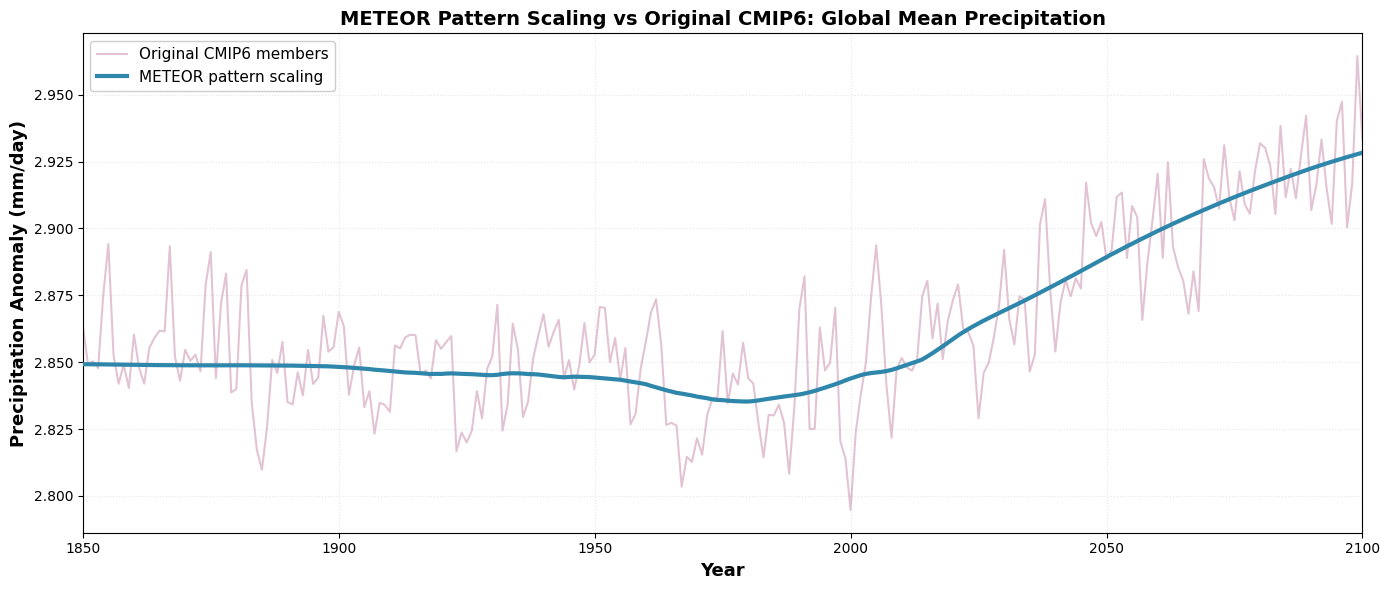


✅ Comparison plot created
   METEOR prediction: 351 years
   Original CMIP6: 251 years
   CMIP6 ensemble members: 1

💡 The METEOR pattern scaling captures the forced precipitation response
   without the internal variability present in individual CMIP6 members.


In [27]:
# Compare METEOR precipitation pattern scaling with original CMIP6 data
print("\n📊 Comparing METEOR precipitation pattern scaling with original CMIP6 data...")

# Get METEOR precipitation prediction (annual global mean)
meteor_pr_prediction_global = prpatt.global_mean(pr_prediction).values+np.mean(original_pr_pictrl_annual_mean).values

# Create time axes
years_pr_original = np.arange(1850, 1850 + len(original_pr_ssp245_annual_mean.values[0]))
years_pr_meteor = np.arange(0, len(meteor_pr_prediction_global)) + 1750  # Starts at year 0

# Convert units: kg/m²/s to mm/day
# 1 kg/m²/s = 86400 mm/day (since 1 kg/m² of water = 1 mm depth)
meteor_pr_mm_day = meteor_pr_prediction_global * 86400
original_pr_mm_day = original_pr_ssp245_annual_mean.values * 86400

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original CMIP6 ensemble members
for i in range(pr_ssp245_annual.shape[0]):
    ax.plot(years_pr_original, original_pr_mm_day[i], 
            color='#A23B72', alpha=0.3, linewidth=1.5, 
            label='Original CMIP6 members' if i == 0 else '')

# Plot METEOR prediction
ax.plot(years_pr_meteor, meteor_pr_mm_day, 
        color='#2E86AB', linewidth=3, label='METEOR pattern scaling', 
        linestyle='-', zorder=10)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation Anomaly (mm/day)', fontsize=13, fontweight='bold')
ax.set_title('METEOR Pattern Scaling vs Original CMIP6: Global Mean Precipitation', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.show()

print(f"\n✅ Comparison plot created")
print(f"   METEOR prediction: {len(meteor_pr_prediction_global)} years")
print(f"   Original CMIP6: {len(original_pr_ssp245_annual_mean.values[0])} years")
print(f"   CMIP6 ensemble members: {pr_ssp245_annual.shape[0]}")
print("\n💡 The METEOR pattern scaling captures the forced precipitation response")
print("   without the internal variability present in individual CMIP6 members.")

In [42]:
# Train precipitation noise model from CMIP6 data
print("🎲 Setting up precipitation noise model...")

# Get cache path for noise model
pr_noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")
pr_noise_cache_file = pr_data_getter.get_noise_model_cache_path(
    pr_model_name, "pr", pr_noise_cache_dir
)

# Validate cache
is_valid_pr_noise, pr_noise_model, pr_noise_info = pr_data_getter.validate_noise_model_cache(
    pr_noise_cache_file, "pr", n_modes=40, lag_order=2
)

print(f"⚠️  {pr_noise_info['message']}")
print(f"🔧 Training precipitation noise model...")

pr_noise_model = train_noise_model_from_cmip6(
    pr_data_getter,
    experiments=["historical", "ssp245"],
    model_name=pr_model_name,
    variable_name="pr",
    n_modes=100,
    lag_order=2,
    custom_global_temp=monthly_warming_trimmed,
    use_picontrol_baseline=True,
    cache_dir=None,  # Don't cache this version
    save_diagnostics=True,  # ← Enable diagnostics!
    use_exog='none'
)



INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr


🎲 Setting up precipitation noise model...
⚠️  Cache file not found: /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/NorESM2-MM_pr_noise_model.pkl
🔧 Training precipitation noise model...


INFO: Loading data from cache: NorESM2-MM_piControl_pr_yearly.nc
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr
INFO: ✓ Using cached yearly data for NorESM2-MM/piControl/pr


   Fetched piControl baseline for NorESM2-MM pr: 0.000
   📊 Diagnostic outputs saved:
      X_features shape: (3012, 9)
      t_glob shape: (3012,)
      time shape: (3012,)
   📊 Seasonal model diagnostics saved:
      Coefficients shape: (55296, 9) (gridpoints × features)
      Intercept shape: (55296,)
      Y data shape: (3012, 55296) (time × gridpoints)
   📊 Seasonal model diagnostics saved:
      Coefficients shape: (55296, 9) (gridpoints × features)
      Intercept shape: (55296,)
      Y data shape: (3012, 55296) (time × gridpoints)
Noise generator fitted successfully.
   - PCA modes: 100
   - Variance explained: 59.93%
   - VARX lag order: 2
   - Exogenous vars: none (pure VAR)
Noise generator fitted successfully.
   - PCA modes: 100
   - Variance explained: 59.93%
   - VARX lag order: 2
   - Exogenous vars: none (pure VAR)


In [43]:

# Access the diagnostic outputs
X_from_model = pr_noise_model.diagnostic_X_features
intercepts_from_model = pr_noise_model.diagnostic_seasonal_intercept
t_glob_from_model = pr_noise_model.diagnostic_t_glob
time_from_model = pr_noise_model.diagnostic_time
Y_from_model= pr_noise_model.diagnostic_Y_data

In [44]:
# Generate precipitation ensemble for global mean
print("🌧️  Generating precipitation ensemble...")

n_pr_demo = 100  # Generate 100 members for demonstration

# Generate stochastic PCs for precipitation
pr_demo_pcs = pr_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_pr_demo,
    random_seed=789
)
print(f"✅ Generated {n_pr_demo} stochastic PCs for precipitation")

# Get piControl baseline for global mean
pr_pictrl_data = pr_data_getter.make_meteor_training_data(
    "piControl", 
    pr_model_name, 
    monthly=True
)["pr"]

pr_picontrol_global_baseline = prpatt.global_mean(pr_pictrl_data).mean()
print(f"   Global piControl precipitation baseline: {pr_picontrol_global_baseline.values:.6e} kg/m²/s ({pr_picontrol_global_baseline.values * 86400:.3f} mm/day)")

# Get pattern scaling prediction (anomaly) and add baseline
pr_annual_prediction = pr_pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["pr"]
)["pr"]
## LOOK AT TO_MONTHLY
    # Convert annual predictions to monthly
pr_monthly_prediction = pattern_model.to_monthly(pr_annual_prediction, start_year=0)

pr_monthly_prediction_global_absolute = pr_monthly_prediction + pr_picontrol_global_baseline
# Generate global mean ensemble
pr_demo_global = pr_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=pr_demo_pcs,
    noise_only=True,
    add_base=pr_monthly_prediction
)
print(f"✅ Global precipitation ensemble: {pr_demo_global.shape}")

# Load original CESM2 precipitation data
print("\n📥 Loading original CMIP6 global precipitation data...")
pr_ssp245_data = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=True
)["pr"]

# Calculate global mean for original data
original_pr_global = prpatt.global_mean(pr_ssp245_data)

print(f"✅ Original CMIP6 global precipitation loaded")
print(f"   Shape: {pr_ssp245_data.shape}")

🌧️  Generating precipitation ensemble...


INFO: Loading data from cache: NorESM2-MM_piControl_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/piControl/pr


✅ Generated 100 stochastic PCs for precipitation


   Global piControl precipitation baseline: 3.296076e-05 kg/m²/s (2.848 mm/day)
11
12
113
114
115
22
141
123
142


INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc


✅ Global precipitation ensemble: (100, 4212)

📥 Loading original CMIP6 global precipitation data...


INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr


✅ Original CMIP6 global precipitation loaded
   Shape: (1, 3012, 192, 288)


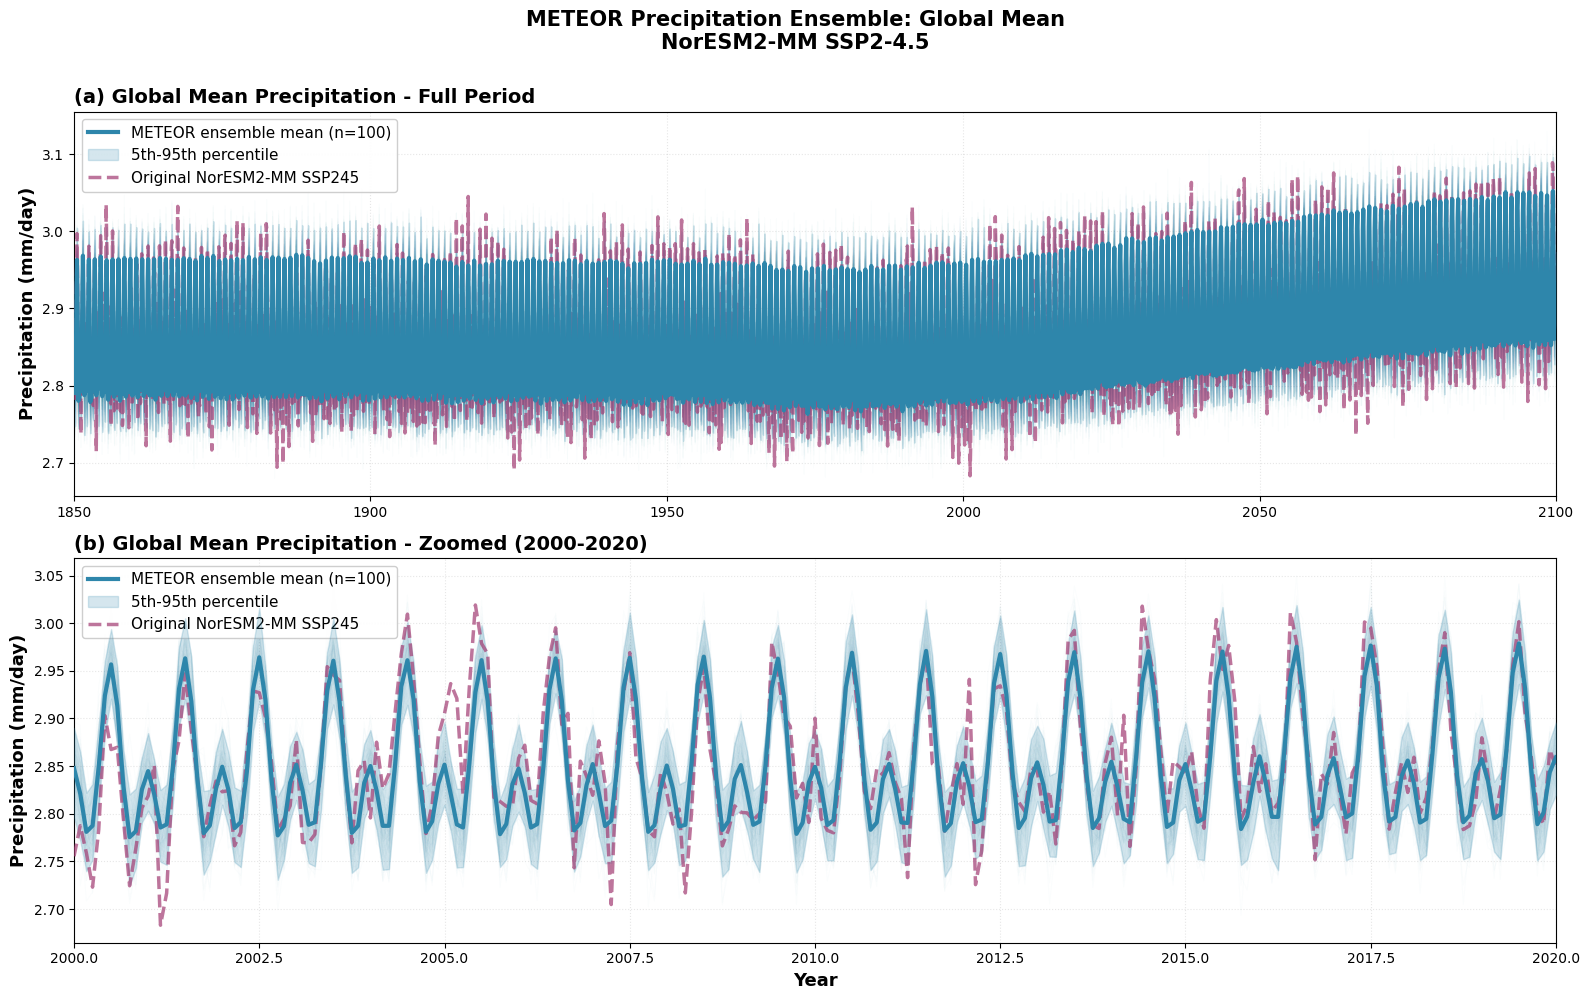


✅ Global mean precipitation ensemble plot created
   Ensemble size: 100 members
   Period: 1850-2100


In [45]:
# Plot global mean precipitation ensemble
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
        
# Convert to mm/day for plotting
pr_monthly_prediction_global_mm = (pr_monthly_prediction_global_absolute) * 86400
pr_demo_global_mm = (pr_demo_global + pr_picontrol_global_baseline) * 86400
original_pr_global_mm = original_pr_global * 86400

# Time axis
time_axis_pr = pr_ssp245_data['month'].values / 12 + 1850
offset = 1200  # Skip first 100 years

# Panel 1: Full period (1850-2100)
ax = axes[0]

# Plot ensemble members with transparency
for i in range(n_pr_demo):
    member_data = pr_demo_global_mm.isel(realization=i).values[offset:]
    time_mask_full = (time_axis_pr >= 1850) & (time_axis_pr <= 2100)
    ax.plot(time_axis_pr[time_mask_full], member_data[time_mask_full], 
            color='#2E86AB', alpha=0.015, linewidth=0.8)

# Plot ensemble mean
ensemble_mean_pr = pr_demo_global_mm.mean(dim='realization').values[offset:]
time_mask_full = (time_axis_pr >= 1850) & (time_axis_pr <= 2100)
ax.plot(time_axis_pr[time_mask_full], ensemble_mean_pr[time_mask_full], 
        color='#2E86AB', linewidth=3, label=f'METEOR ensemble mean (n={n_pr_demo})', zorder=10)

# Plot percentiles
perc_05_pr = pr_demo_global_mm.quantile(0.05, dim='realization').values[offset:]
perc_95_pr = pr_demo_global_mm.quantile(0.95, dim='realization').values[offset:]
ax.fill_between(time_axis_pr[time_mask_full], perc_05_pr[time_mask_full], perc_95_pr[time_mask_full],
                color='#2E86AB', alpha=0.2, label='5th-95th percentile', zorder=7)

# Plot original CMIP6 data
ax.plot(time_axis_pr[time_mask_full], original_pr_global_mm.values[:, time_mask_full].T, 
        color='#A23B72', linewidth=2.5, linestyle='--',
        label=f'Original {pr_model_name} SSP245', zorder=9, alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Precipitation - Full Period', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

# Panel 2: Zoomed period (2000-2020)
ax = axes[1]
zoom_start, zoom_end = 2000, 2020

# Plot ensemble members
for i in range(n_pr_demo):
    member_data = pr_demo_global_mm.isel(realization=i).values[offset:]
    time_mask_zoom = (time_axis_pr >= zoom_start) & (time_axis_pr <= zoom_end)
    ax.plot(time_axis_pr[time_mask_zoom], member_data[time_mask_zoom], 
            color='#2E86AB', alpha=0.015, linewidth=0.8)

# Plot ensemble mean
time_mask_zoom = (time_axis_pr >= zoom_start) & (time_axis_pr <= zoom_end)
ax.plot(time_axis_pr[time_mask_zoom], ensemble_mean_pr[time_mask_zoom], 
        color='#2E86AB', linewidth=3, label=f'METEOR ensemble mean (n={n_pr_demo})', zorder=10)

# Plot percentiles
ax.fill_between(time_axis_pr[time_mask_zoom], perc_05_pr[time_mask_zoom], perc_95_pr[time_mask_zoom],
                color='#2E86AB', alpha=0.2, label='5th-95th percentile', zorder=7)

# Plot original CMIP6 data
ax.plot(time_axis_pr[time_mask_zoom], original_pr_global_mm.values[:, time_mask_zoom].T, 
         color='#A23B72', linewidth=2.5, linestyle='--',
         label=f'Original {pr_model_name} SSP245', zorder=9, alpha=0.7)

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation (mm/day)', fontsize=13, fontweight='bold')
ax.set_title(f'(b) Global Mean Precipitation - Zoomed ({zoom_start}-{zoom_end})', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(zoom_start, zoom_end)

plt.suptitle(f'METEOR Precipitation Ensemble: Global Mean\n{pr_model_name} SSP2-4.5', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"\n✅ Global mean precipitation ensemble plot created")
print(f"   Ensemble size: {n_pr_demo} members")
print(f"   Period: 1850-2100")

In [48]:
list_ar6_regions()

AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian-Peninsula
  SAS    

In [63]:
# 🌧️ Comprehensive Precipitation Ensemble Demonstration
# Generate global, regional, and point-location simulations

print("="*80)
print("PRECIPITATION NOISE MODEL: Multi-Scale Ensemble Generation")
print("="*80)

# Configuration
n_ensemble = 100
random_seed = 42
zoom_start, zoom_end = 2000, 2020

# Target locations for point simulations
locations = {
    'Seattle': {'lat': 47.6, 'lon': -122.3 + 360},  # Convert to 0-360
    'Amazon': {'lat': -3.0, 'lon': -60.0 + 360},
    'Sahel': {'lat': 12.0, 'lon': 0.0},
    'Mumbai': {'lat': 19.1, 'lon': 72.9}
}

print(f"\n📊 Configuration:")
print(f"   Ensemble size: {n_ensemble}")
print(f"   Random seed: {random_seed}")
print(f"   Zoom period: {zoom_start}-{zoom_end}")

# ============================================================================
# STEP 1: Generate shared stochastic PCs (ensures consistency across scales)
# ============================================================================
print("\n🎲 Step 1: Generate stochastic PCs...")
pr_pcs = pr_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_ensemble,
    random_seed=random_seed
)
print(f"   ✅ PCs generated: {pr_pcs.shape}")

# ============================================================================
# STEP 2: Generate global mean realizations
# ============================================================================
print("\n🌍 Step 2: Generate global mean ensemble...")
pr_global_ensemble = pr_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=pr_pcs,
    noise_only=True,
    add_base=pr_monthly_prediction
)
pr_global_ensemble_mm = (pr_global_ensemble + pr_picontrol_global_baseline) * 86400
print(f"   ✅ Global ensemble: {pr_global_ensemble.shape} → mm/day")

# ============================================================================
# STEP 3: Generate regional mean realizations
# ============================================================================
print("\n🗺️  Step 3: Generate regional mean ensemble...")
region_name = 'EAS'  # East Asia
pr_regional = pr_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region=region_name,
    stochastic_pcs=pr_pcs,
    noise_only=True,
    add_base=pr_monthly_prediction
)
pr_regional_ensemble_mm = (pr_regional + pr_picontrol_global_baseline) * 86400
print(f"   ✅ {region_name}: {pr_regional.shape} → mm/day")

# ============================================================================
# STEP 4: Generate point-location realizations
# ============================================================================
print("\n📍 Step 4: Generate point-location ensemble...")
point_name = 'Mumbai'
point_coords = {'lat': 19.1, 'lon': 72.9}

pr_point = pr_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='point',
    lat=point_coords['lat'],
    lon=point_coords['lon'],
    stochastic_pcs=pr_pcs,
    noise_only=True,
    add_base=pr_monthly_prediction
)
pr_point_ensemble_mm = (pr_point + pr_picontrol_global_baseline) * 86400
print(f"   ✅ {point_name} ({point_coords['lat']:.1f}°, {point_coords['lon']:.1f}°): {pr_point.shape} → mm/day")

# ============================================================================
# STEP 5: Load original CMIP6 data for comparison
# ============================================================================
print("\n📥 Step 5: Load original CMIP6 data...")
pr_ssp245_monthly = pr_data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    pr_model_name, 
    monthly=True
)["pr"]

# Calculate global mean
original_pr_global_mm = prpatt.global_mean(pr_ssp245_monthly) * 86400
print(f"   ✅ Original CMIP6 global: {original_pr_global_mm.shape}")

# Calculate regional mean using the defined function
original_pr_regional_mm = calculate_regional_mean(pr_ssp245_monthly, region_name) * 86400
print(f"   ✅ Original CMIP6 regional ({region_name}): {original_pr_regional_mm.shape}")

# Calculate point location mean for Mumbai
lat_idx = np.argmin(np.abs(pr_ssp245_monthly.lat.values - point_coords['lat']))
lon_idx = np.argmin(np.abs(pr_ssp245_monthly.lon.values - point_coords['lon']))
original_pr_point_mm = pr_ssp245_monthly.isel(lat=lat_idx, lon=lon_idx) * 86400
print(f"   ✅ Original CMIP6 point ({point_name}): {original_pr_point_mm.shape}")

# ============================================================================
# STEP 6: Create time axes and align data
# ============================================================================
print("\n🕐 Step 6: Create time axes...")

# METEOR ensemble time axis (based on monthly_warming length)
n_meteor_months = len(monthly_warming)
time_axis_meteor = np.arange(n_meteor_months) / 12 + 1750  # METEOR starts at year 1750
print(f"   METEOR time axis: {n_meteor_months} months ({time_axis_meteor[0]:.1f} - {time_axis_meteor[-1]:.1f})")

# Original CMIP6 time axis
time_axis_cmip6 = pr_ssp245_monthly['month'].values / 12 + 1850
n_cmip6_months = len(time_axis_cmip6)
print(f"   CMIP6 time axis:  {n_cmip6_months} months ({time_axis_cmip6[0]:.1f} - {time_axis_cmip6[-1]:.1f})")

# Find overlap period
meteor_start_year = time_axis_meteor[0]
meteor_end_year = time_axis_meteor[-1]
cmip6_start_year = time_axis_cmip6[0]
cmip6_end_year = time_axis_cmip6[-1]

overlap_start = max(meteor_start_year, cmip6_start_year)
overlap_end = min(meteor_end_year, cmip6_end_year)
print(f"   Overlap period: {overlap_start:.1f} - {overlap_end:.1f}")

print("\n" + "="*80)
print("✅ All ensembles generated successfully!")
print("="*80)

PRECIPITATION NOISE MODEL: Multi-Scale Ensemble Generation

📊 Configuration:
   Ensemble size: 100
   Random seed: 42
   Zoom period: 2000-2020

🎲 Step 1: Generate stochastic PCs...
   ✅ PCs generated: (100, 4212, 100)

🌍 Step 2: Generate global mean ensemble...
   ✅ PCs generated: (100, 4212, 100)

🌍 Step 2: Generate global mean ensemble...
   ✅ Global ensemble: (100, 4212) → mm/day

🗺️  Step 3: Generate regional mean ensemble...
   ✅ Global ensemble: (100, 4212) → mm/day

🗺️  Step 3: Generate regional mean ensemble...
   ✅ EAS: (100, 4212) → mm/day

📍 Step 4: Generate point-location ensemble...
   ✅ EAS: (100, 4212) → mm/day

📍 Step 4: Generate point-location ensemble...


INFO: Loading data from cache: NorESM2-MM_historical_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/historical/pr
INFO: Loading data from cache: NorESM2-MM_ssp245_pr_monthly.nc
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr
INFO: ✓ Using cached monthly data for NorESM2-MM/ssp245/pr


   ✅ Mumbai (19.1°, 72.9°): (100, 4212) → mm/day

📥 Step 5: Load original CMIP6 data...
   ✅ Original CMIP6 global: (1, 3012)
   ✅ Original CMIP6 global: (1, 3012)
   ✅ Original CMIP6 regional (EAS): (1, 3012)
   ✅ Original CMIP6 point (Mumbai): (1, 3012)

🕐 Step 6: Create time axes...
   METEOR time axis: 4212 months (1750.0 - 2100.9)
   CMIP6 time axis:  3012 months (1850.0 - 2100.9)
   Overlap period: 1850.0 - 2100.9

✅ All ensembles generated successfully!
   ✅ Original CMIP6 regional (EAS): (1, 3012)
   ✅ Original CMIP6 point (Mumbai): (1, 3012)

🕐 Step 6: Create time axes...
   METEOR time axis: 4212 months (1750.0 - 2100.9)
   CMIP6 time axis:  3012 months (1850.0 - 2100.9)
   Overlap period: 1850.0 - 2100.9

✅ All ensembles generated successfully!


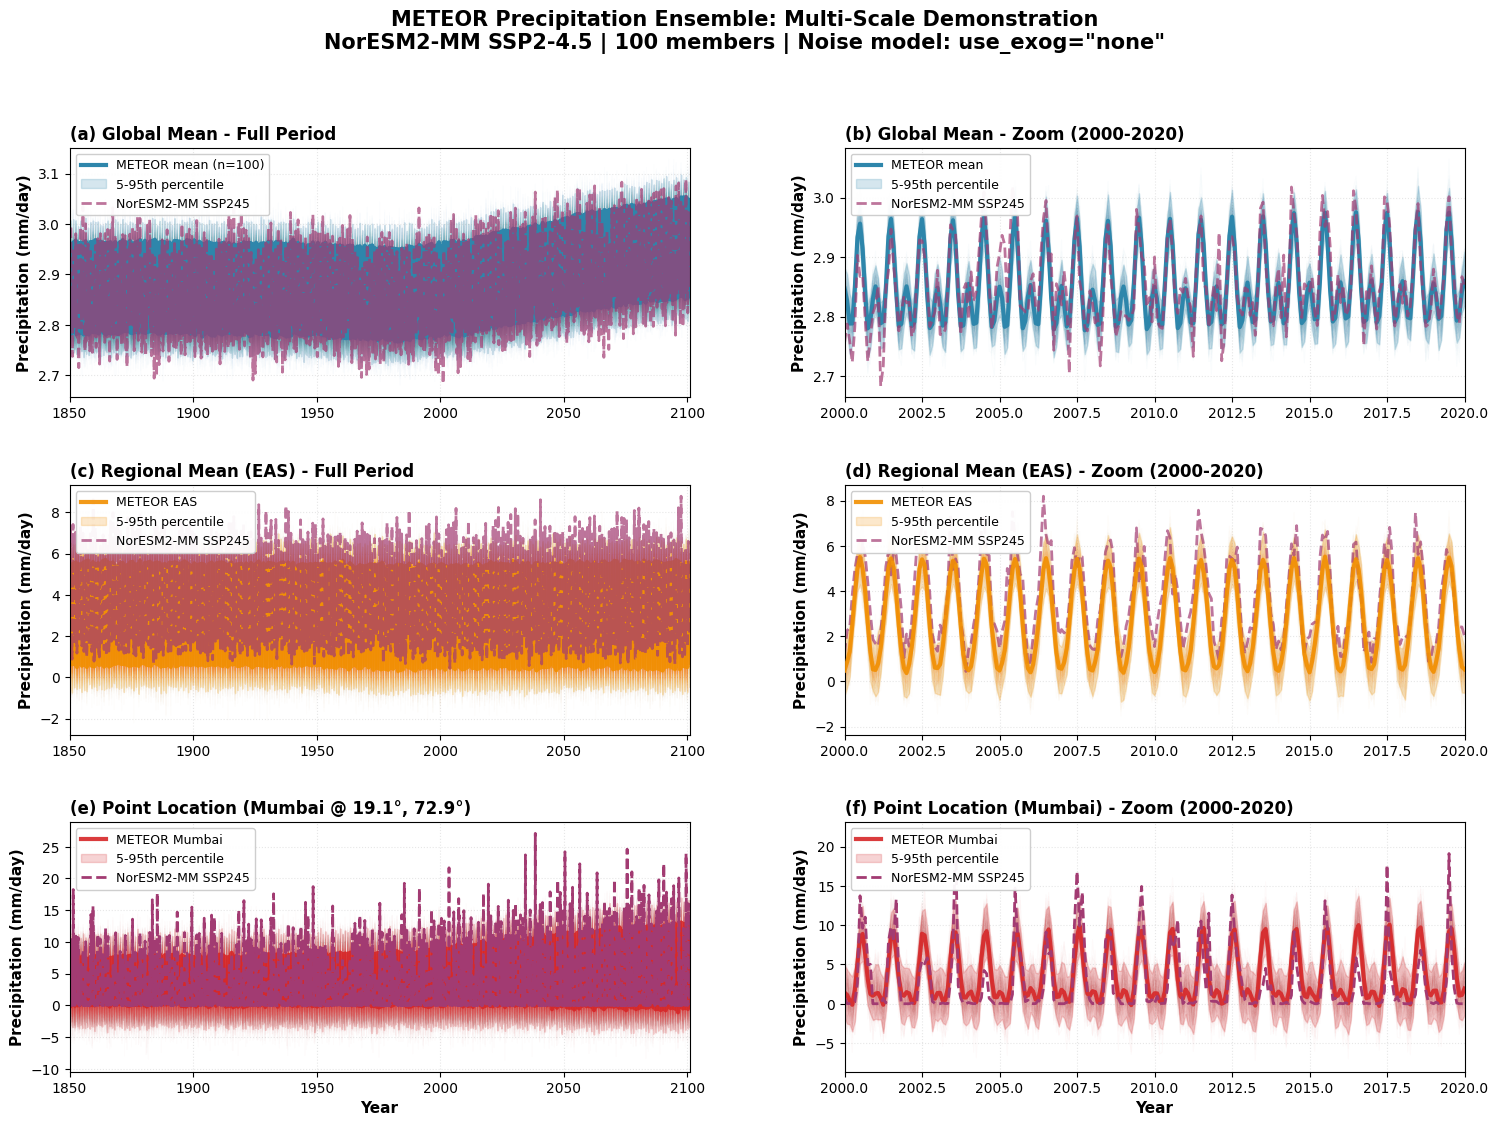


✅ 6-panel precipitation ensemble plot complete!
   Global: ✓ | Regional (EAS): ✓ | Point (Mumbai): ✓
   All panels now include CMIP6 comparison!


In [73]:
# 📊 VISUALIZATION: 6-Panel Precipitation Ensemble (Global, Regional, Point)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# Create time masks for zoomed period
time_mask_meteor_zoom = (time_axis_meteor >= zoom_start) & (time_axis_meteor <= zoom_end)
time_mask_cmip6_zoom = (time_axis_cmip6 >= zoom_start) & (time_axis_cmip6 <= zoom_end)

colors = {'METEOR': '#2E86AB', 'CMIP6': '#A23B72', 'region': '#F18F01', 'point': '#D62728'}

# ============================================================================
# Panel 1: Global Mean - Full Period
# ============================================================================
ax = fig.add_subplot(gs[0, 0])
for i in range(n_ensemble):
    ax.plot(time_axis_meteor, pr_global_ensemble_mm.isel(realization=i).values, 
            color=colors['METEOR'], alpha=0.01, linewidth=0.8)

ensemble_mean = pr_global_ensemble_mm.mean(dim='realization').values
ax.plot(time_axis_meteor, ensemble_mean, 
        color=colors['METEOR'], linewidth=3, label=f'METEOR mean (n={n_ensemble})')

perc_05 = pr_global_ensemble_mm.quantile(0.05, dim='realization').values
perc_95 = pr_global_ensemble_mm.quantile(0.95, dim='realization').values
ax.fill_between(time_axis_meteor, perc_05, perc_95,
                color=colors['METEOR'], alpha=0.2, label='5-95th percentile')

ax.plot(time_axis_cmip6, original_pr_global_mm.values.T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245', alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title('(a) Global Mean - Full Period', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(overlap_start, overlap_end)

# ============================================================================
# Panel 2: Global Mean - Zoomed Period
# ============================================================================
ax = fig.add_subplot(gs[0, 1])
for i in range(n_ensemble):
    ax.plot(time_axis_meteor[time_mask_meteor_zoom], 
            pr_global_ensemble_mm.isel(realization=i).values[time_mask_meteor_zoom], 
            color=colors['METEOR'], alpha=0.02, linewidth=0.8)

ax.plot(time_axis_meteor[time_mask_meteor_zoom], ensemble_mean[time_mask_meteor_zoom], 
        color=colors['METEOR'], linewidth=3, label='METEOR mean')
ax.fill_between(time_axis_meteor[time_mask_meteor_zoom], perc_05[time_mask_meteor_zoom], perc_95[time_mask_meteor_zoom],
                color=colors['METEOR'], alpha=0.2, label='5-95th percentile')

ax.plot(time_axis_cmip6[time_mask_cmip6_zoom], original_pr_global_mm.values[:, time_mask_cmip6_zoom].T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245',  alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title(f'(b) Global Mean - Zoom ({zoom_start}-{zoom_end})', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(zoom_start, zoom_end)

# ============================================================================
# Panel 3: Regional Mean (EAS) - Full Period
# ============================================================================
ax = fig.add_subplot(gs[1, 0])

for i in range(n_ensemble):
    ax.plot(time_axis_meteor, pr_regional_ensemble_mm.isel(realization=i).values, 
            color=colors['region'], alpha=0.01, linewidth=0.8)

regional_mean = pr_regional_ensemble_mm.mean(dim='realization').values
ax.plot(time_axis_meteor, regional_mean, 
        color=colors['region'], linewidth=3, label=f'METEOR {region_name}', alpha=0.9)

perc_05_reg = pr_regional_ensemble_mm.quantile(0.05, dim='realization').values
perc_95_reg = pr_regional_ensemble_mm.quantile(0.95, dim='realization').values
ax.fill_between(time_axis_meteor, perc_05_reg, perc_95_reg,
                color=colors['region'], alpha=0.2, label='5-95th percentile')

# Add original CMIP6 regional data
ax.plot(time_axis_cmip6, original_pr_regional_mm.values.T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245',  alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title(f'(c) Regional Mean ({region_name}) - Full Period', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(overlap_start, overlap_end)

# ============================================================================
# Panel 4: Regional Mean (EAS) - Zoomed Period
# ============================================================================
ax = fig.add_subplot(gs[1, 1])

for i in range(n_ensemble):
    ax.plot(time_axis_meteor[time_mask_meteor_zoom], 
            pr_regional_ensemble_mm.isel(realization=i).values[time_mask_meteor_zoom], 
            color=colors['region'], alpha=0.02, linewidth=0.8)

ax.plot(time_axis_meteor[time_mask_meteor_zoom], regional_mean[time_mask_meteor_zoom], 
        color=colors['region'], linewidth=3, label=f'METEOR {region_name}', alpha=0.9, zorder=10)
ax.fill_between(time_axis_meteor[time_mask_meteor_zoom], perc_05_reg[time_mask_meteor_zoom], perc_95_reg[time_mask_meteor_zoom],
                color=colors['region'], alpha=0.2, label='5-95th percentile')

# Add original CMIP6 regional data
ax.plot(time_axis_cmip6[time_mask_cmip6_zoom], original_pr_regional_mm.values[:, time_mask_cmip6_zoom].T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245',  alpha=0.7)

ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title(f'(d) Regional Mean ({region_name}) - Zoom ({zoom_start}-{zoom_end})', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(zoom_start, zoom_end)

# ============================================================================
# Panel 5: Point Location (Mumbai) - Full Period
# ============================================================================
ax = fig.add_subplot(gs[2, 0])

for i in range(n_ensemble):
    ax.plot(time_axis_meteor, pr_point_ensemble_mm.isel(realization=i).values, 
            color=colors['point'], alpha=0.01, linewidth=0.8)

point_mean = pr_point_ensemble_mm.mean(dim='realization').values
ax.plot(time_axis_meteor, point_mean, 
        color=colors['point'], linewidth=3, 
        label=f'METEOR {point_name}', 
        alpha=0.9)

perc_05_pt = pr_point_ensemble_mm.quantile(0.05, dim='realization').values
perc_95_pt = pr_point_ensemble_mm.quantile(0.95, dim='realization').values
ax.fill_between(time_axis_meteor, perc_05_pt, perc_95_pt,
                color=colors['point'], alpha=0.2, label='5-95th percentile')

# Add original CMIP6 point data
ax.plot(time_axis_cmip6, original_pr_point_mm.values.T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245', alpha=1)

ax.set_xlabel('Year', fontweight='bold', fontsize=11)
ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title(f'(e) Point Location ({point_name} @ {point_coords["lat"]:.1f}°, {point_coords["lon"]:.1f}°)', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(overlap_start, overlap_end)

# ============================================================================
# Panel 6: Point Location (Mumbai) - Zoomed Period
# ============================================================================
ax = fig.add_subplot(gs[2, 1])

for i in range(n_ensemble):
    ax.plot(time_axis_meteor[time_mask_meteor_zoom], 
            pr_point_ensemble_mm.isel(realization=i).values[time_mask_meteor_zoom], 
            color=colors['point'], alpha=0.02, linewidth=0.8)

ax.plot(time_axis_meteor[time_mask_meteor_zoom], point_mean[time_mask_meteor_zoom], 
        color=colors['point'], linewidth=3, label=f'METEOR {point_name}', alpha=0.9)
ax.fill_between(time_axis_meteor[time_mask_meteor_zoom], perc_05_pt[time_mask_meteor_zoom], perc_95_pt[time_mask_meteor_zoom],
                color=colors['point'], alpha=0.2, label='5-95th percentile')

# Add original CMIP6 point data
ax.plot(time_axis_cmip6[time_mask_cmip6_zoom], original_pr_point_mm.values[:, time_mask_cmip6_zoom].T, 
        color=colors['CMIP6'], linewidth=2, linestyle='--',
        label=f'{pr_model_name} SSP245',  alpha=1)

ax.set_xlabel('Year', fontweight='bold', fontsize=11)
ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
ax.set_title(f'(f) Point Location ({point_name}) - Zoom ({zoom_start}-{zoom_end})', fontweight='bold', loc='left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
ax.set_xlim(zoom_start, zoom_end)

# Overall title
plt.suptitle(f'METEOR Precipitation Ensemble: Multi-Scale Demonstration\n{pr_model_name} SSP2-4.5 | {n_ensemble} members | Noise model: use_exog="none"', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

print("\n✅ 6-panel precipitation ensemble plot complete!")
print(f"   Global: ✓ | Regional ({region_name}): ✓ | Point ({point_name}): ✓")
print(f"   All panels now include CMIP6 comparison!")

### Apply Gaussian-to-Gamma Transform for Physical Realism

The generated precipitation may contain negative values. We apply a distribution transform to ensure physical realism while preserving spatial/temporal correlations.

In [141]:
# ============================================================================
# STEP 7: Fit distribution parameters for Gaussian-to-Gamma transform (1D PATH)
# ============================================================================
print("\n" + "="*80)
print("OPTIONAL: Gaussian-to-Gamma Transform for Physical Realism (1D Regional Means)")
print("="*80)

# Check for negative values in generated ensemble
min_global = pr_global_ensemble_mm.min().values
min_regional = pr_regional_ensemble_mm.min().values
min_point = pr_point_ensemble_mm.min().values

print(f"\n📊 Checking for negative precipitation values:")
print(f"   Global ensemble minimum:   {min_global:.4f} mm/day")
print(f"   Regional ensemble minimum: {min_regional:.4f} mm/day")
print(f"   Point ensemble minimum:    {min_point:.4f} mm/day")

if min_global < 0 or min_regional < 0 or min_point < 0:
    print("\n⚠️  Negative values detected - applying 1D distribution transform...")
    
    # ========================================================================
    # PATH 1: 1D Transform for Regional/Global Means
    # ========================================================================
    # This is efficient because we're working with 1D time series outputs
    # from generate_regional_mean_realizations(), not gridded fields
    
    print("\n🔧 Using 1D transform path (fitting to regional mean time series)...")
    print(f"   Data shape: (n_realizations={n_ensemble}, n_time={len(time_axis_cmip6)})")
    
    # FIT DISTRIBUTIONS
    print("\n📐 Fitting distributions...")
    print("   Strategy: Fit Gaussian to GENERATED data, Gamma to CMIP6 TARGET")
    
    # Global mean
    print("\n   Global mean:")
    print("     Fitting Gaussian to generated ensemble...")
    gaussian_params_global = fit_distribution_parameters_1d(
        pr_global_ensemble_mm, 
        distribution='gaussian'
    )
    print(f"       ✅ μ={gaussian_params_global['mean']:.3f}, σ={gaussian_params_global['std']:.3f} mm/day")
    
    print("     Fitting Gamma to CMIP6 target...")
    gamma_params_global = fit_distribution_parameters_1d(
        original_pr_global_mm,
        distribution='gamma'
    )
    print(f"       ✅ α={gamma_params_global['shape']:.3f}, β={gamma_params_global['scale']:.3f}")
    
    # Regional mean
    print(f"\n   Regional mean ({region_name}):")
    print("     Fitting Gaussian to generated ensemble...")
    gaussian_params_regional = fit_distribution_parameters_1d(
        pr_regional_ensemble_mm,
        distribution='gaussian'
    )
    print(f"       ✅ μ={gaussian_params_regional['mean']:.3f}, σ={gaussian_params_regional['std']:.3f} mm/day")
    
    print("     Fitting Gamma to CMIP6 target...")
    gamma_params_regional = fit_distribution_parameters_1d(
        original_pr_regional_mm,
        distribution='gamma'
    )
    print(f"       ✅ α={gamma_params_regional['shape']:.3f}, β={gamma_params_regional['scale']:.3f}")
    
    # Point location
    print(f"\n   Point location ({point_name}):")
    print("     Fitting Gaussian to generated ensemble...")
    gaussian_params_point = fit_distribution_parameters_1d(
        pr_point_ensemble_mm,
        distribution='gaussian'
    )
    print(f"       ✅ μ={gaussian_params_point['mean']:.3f}, σ={gaussian_params_point['std']:.3f} mm/day")
    
    print("     Fitting Gamma to CMIP6 target...")
    params_point = fit_distribution_parameters_1d(
        original_pr_point_mm,
        distribution='gamma'
    )
    
    # APPLY TRANSFORMS
    print("\n🔄 Applying distribution transforms...")
    
    # Global
    pr_global_ensemble_mm_gamma = apply_distribution_transform(
        pr_global_ensemble_mm,
        gaussian_params_global,
        gamma_params_global
    )
    print(f"   ✅ Global:   {min_global:.4f} → {pr_global_ensemble_mm_gamma.min().values:.4f} mm/day")
    
    # Regional
    pr_regional_ensemble_mm_gamma = apply_distribution_transform(
        pr_regional_ensemble_mm,
        gaussian_params_regional,
        gamma_params_regional
    )
    print(f"   ✅ Regional: {min_regional:.4f} → {pr_regional_ensemble_mm_gamma.min().values:.4f} mm/day")
    
    # Point
    pr_point_ensemble_mm_gamma = apply_distribution_transform(
        pr_point_ensemble_mm,
        gaussian_params_point,
        params_point
    )
    print(f"   ✅ Point:    {min_point:.4f} → {pr_point_ensemble_mm_gamma.min().values:.4f} mm/day")
    
    print("\n💡 1D Transform Benefits:")
    print("   • Fast: Only 3 distribution fits (global, regional, point)")
    print("   • Memory efficient: Only 6 scalar parameters total")
    print("   • Statistically appropriate: Fits match aggregation level of generated data")
    print("   • Preserves correlations: Spatial/temporal structure maintained")
    
    print("\n📝 Note: For gridded output from generate_realization(), use:")
    print("   fit_distribution_parameters_3d() - fits distribution at each grid point")
    
else:
    print("\n✅ No negative values found - no transform needed!")
    pr_global_ensemble_mm_gamma = pr_global_ensemble_mm
    pr_regional_ensemble_mm_gamma = pr_regional_ensemble_mm
    pr_point_ensemble_mm_gamma = pr_point_ensemble_mm

print("\n" + "="*80)


OPTIONAL: Gaussian-to-Gamma Transform for Physical Realism (1D Regional Means)

📊 Checking for negative precipitation values:
   Global ensemble minimum:   2.6784 mm/day
   Regional ensemble minimum: -2.2261 mm/day
   Point ensemble minimum:    -8.6491 mm/day

⚠️  Negative values detected - applying 1D distribution transform...

🔧 Using 1D transform path (fitting to regional mean time series)...
   Data shape: (n_realizations=100, n_time=3012)

📐 Fitting distributions...
   Strategy: Fit Gaussian to GENERATED data, Gamma to CMIP6 TARGET

   Global mean:
     Fitting Gaussian to generated ensemble...
       ✅ μ=2.858, σ=0.068 mm/day
     Fitting Gamma to CMIP6 target...
       ✅ α=1547.484, β=0.002

   Regional mean (EAS):
     Fitting Gaussian to generated ensemble...
       ✅ μ=2.807, σ=1.891 mm/day
     Fitting Gamma to CMIP6 target...
       ✅ α=3.543, β=1.068

   Point location (Mumbai):
     Fitting Gaussian to generated ensemble...
       ✅ μ=3.200, σ=3.755 mm/day
     Fitting G

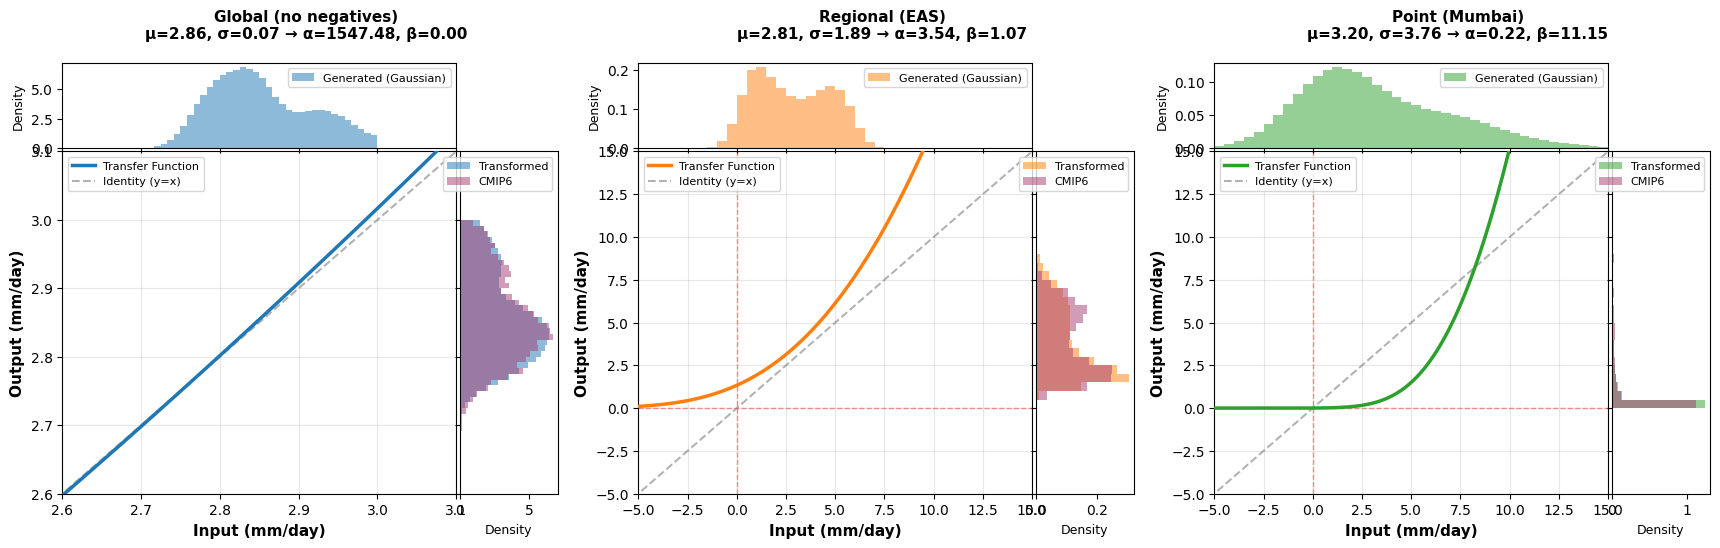


📊 Transfer Function with Marginal Distributions:
   • Top histogram: Generated Gaussian precipitation (input)
   • Right histogram: Transformed (orange/blue/green) vs CMIP6 (purple) output
   • Transfer curve shows how inputs are mapped to outputs
   • Transform preserves rank order but reshapes distribution to match CMIP6


In [142]:
# ============================================================================
# Visualize Transfer Functions for Three Spatial Scales with Marginal Histograms
# ============================================================================
if min_regional < 0 or min_point < 0:
    from scipy import stats
    from matplotlib.gridspec import GridSpec
    
    # Prepare data for the three scales
    scales_data = [
        ('Global', pr_global_ensemble_mm, pr_global_ensemble_mm_gamma, 
         original_pr_global_mm, gaussian_params_global, gamma_params_global, '#1f77b4', min_global),
        ('Regional (EAS)', pr_regional_ensemble_mm, pr_regional_ensemble_mm_gamma,
         original_pr_regional_mm, gaussian_params_regional, gamma_params_regional, '#ff7f0e', min_regional),
        ('Point (Mumbai)', pr_point_ensemble_mm, pr_point_ensemble_mm_gamma,
         original_pr_point_mm, gaussian_params_point, gamma_params_point, '#2ca02c', min_point)
    ]
    
    fig = plt.figure(figsize=(18, 6))
    
    for idx, (scale_name, data_orig, data_gamma, cmip_data, gauss_params, gamma_params, color, min_val) in enumerate(scales_data):
        # Create grid for main plot + marginal histograms
        gs = GridSpec(3, 3, figure=fig, 
                      left=0.05 + idx*0.32, right=0.05 + idx*0.32 + 0.28,
                      bottom=0.15, top=0.88,
                      hspace=0.02, wspace=0.02,
                      height_ratios=[1, 4, 0.05], width_ratios=[0.05, 4, 1])
        
        ax_main = fig.add_subplot(gs[1, 1])
        ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
        
        # Create transfer function curve
        x_range = np.linspace(-10, 20, 1000)
        uniform_cdf = stats.norm.cdf(x_range, loc=gauss_params['mean'], scale=gauss_params['std'])
        uniform_cdf = np.clip(uniform_cdf, 1e-10, 1-1e-10)
        y_gamma = stats.gamma.ppf(uniform_cdf, a=gamma_params['shape'], scale=gamma_params['scale'])
        
        # Main plot: Transfer function
        ax_main.plot(x_range, y_gamma, linewidth=2.5, color=color, label='Transfer Function', zorder=3)
        ax_main.plot(x_range, x_range, '--', color='gray', linewidth=1.5, alpha=0.6, label='Identity (y=x)', zorder=2)
        ax_main.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
        ax_main.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
        ax_main.grid(True, alpha=0.3, zorder=0)
        ax_main.set_xlabel('Input (mm/day)', fontweight='bold', fontsize=11)
        ax_main.set_ylabel('Output (mm/day)', fontweight='bold', fontsize=11)
        ax_main.legend(fontsize=8, loc='upper left')
        
        # Set histogram bin ranges based on scale
        if idx == 0:  # Global
            hist_range = (2.5, 3.0)
            hist_bins = 60
        else:  # Regional and Point
            hist_range = (-10, 20)
            hist_bins = 60
        
        # Top histogram: Generated Gaussian distribution (X-axis) - Always use PDF
        ax_top.hist(data_orig.values.flatten(), bins=hist_bins, range=hist_range, 
                    alpha=0.5, color=color, density=True, label='Generated (Gaussian)')
        ax_top.set_ylabel('Density', fontsize=9)
        ax_top.tick_params(labelbottom=False)
        ax_top.legend(fontsize=8, loc='upper right')
        ax_top.set_ylim(bottom=0)
        
        # Right histogram: Transformed and CMIP6 distributions (Y-axis) - Always use PDF
        # Plot horizontally (swap x and y)
        counts_gamma, bins_gamma = np.histogram(data_gamma.values.flatten(), bins=hist_bins, 
                                                range=hist_range, density=True)
        counts_cmip, bins_cmip = np.histogram(cmip_data.values.flatten(), bins=hist_bins, 
                                              range=hist_range, density=True)
        
        # Plot as horizontal bars
        bin_centers_gamma = (bins_gamma[:-1] + bins_gamma[1:]) / 2
        bin_centers_cmip = (bins_cmip[:-1] + bins_cmip[1:]) / 2
        bin_width_gamma = bins_gamma[1] - bins_gamma[0]
        bin_width_cmip = bins_cmip[1] - bins_cmip[0]
        
        ax_right.barh(bin_centers_gamma, counts_gamma, height=bin_width_gamma, 
                      alpha=0.5, color=color, label='Transformed')
        ax_right.barh(bin_centers_cmip, counts_cmip, height=bin_width_cmip, 
                      alpha=0.5, color='#A23B72', label='CMIP6')
        ax_right.set_xlabel('Density', fontsize=9)
        ax_right.tick_params(labelleft=False)
        ax_right.legend(fontsize=8, loc='upper right')
        ax_right.set_xlim(left=0)
        
        # Set consistent axis limits
        if idx == 0:  # Global
            ax_main.set_xlim(2.6, 3.1)
            ax_main.set_ylim(2.6, 3.1)
        else:  # Regional and Point
            ax_main.set_xlim(-5, 15)
            ax_main.set_ylim(-5, 15)
        
        # Title
        if min_val < 0:
            title_text = f'{scale_name}\nμ={gauss_params["mean"]:.2f}, σ={gauss_params["std"]:.2f} → α={gamma_params["shape"]:.2f}, β={gamma_params["scale"]:.2f}'
        else:
            title_text = f'{scale_name} (no negatives)\nμ={gauss_params["mean"]:.2f}, σ={gauss_params["std"]:.2f} → α={gamma_params["shape"]:.2f}, β={gamma_params["scale"]:.2f}'
        
        fig.text(0.05 + idx*0.32 + 0.14, 0.92, title_text, 
                 ha='center', fontweight='bold', fontsize=11)
    
    plt.show()
    
    print("\n📊 Transfer Function with Marginal Distributions:")
    print("   • Top histogram: Generated Gaussian precipitation (input)")
    print("   • Right histogram: Transformed (orange/blue/green) vs CMIP6 (purple) output")
    print("   • Transfer curve shows how inputs are mapped to outputs")
    print("   • Transform preserves rank order but reshapes distribution to match CMIP6")

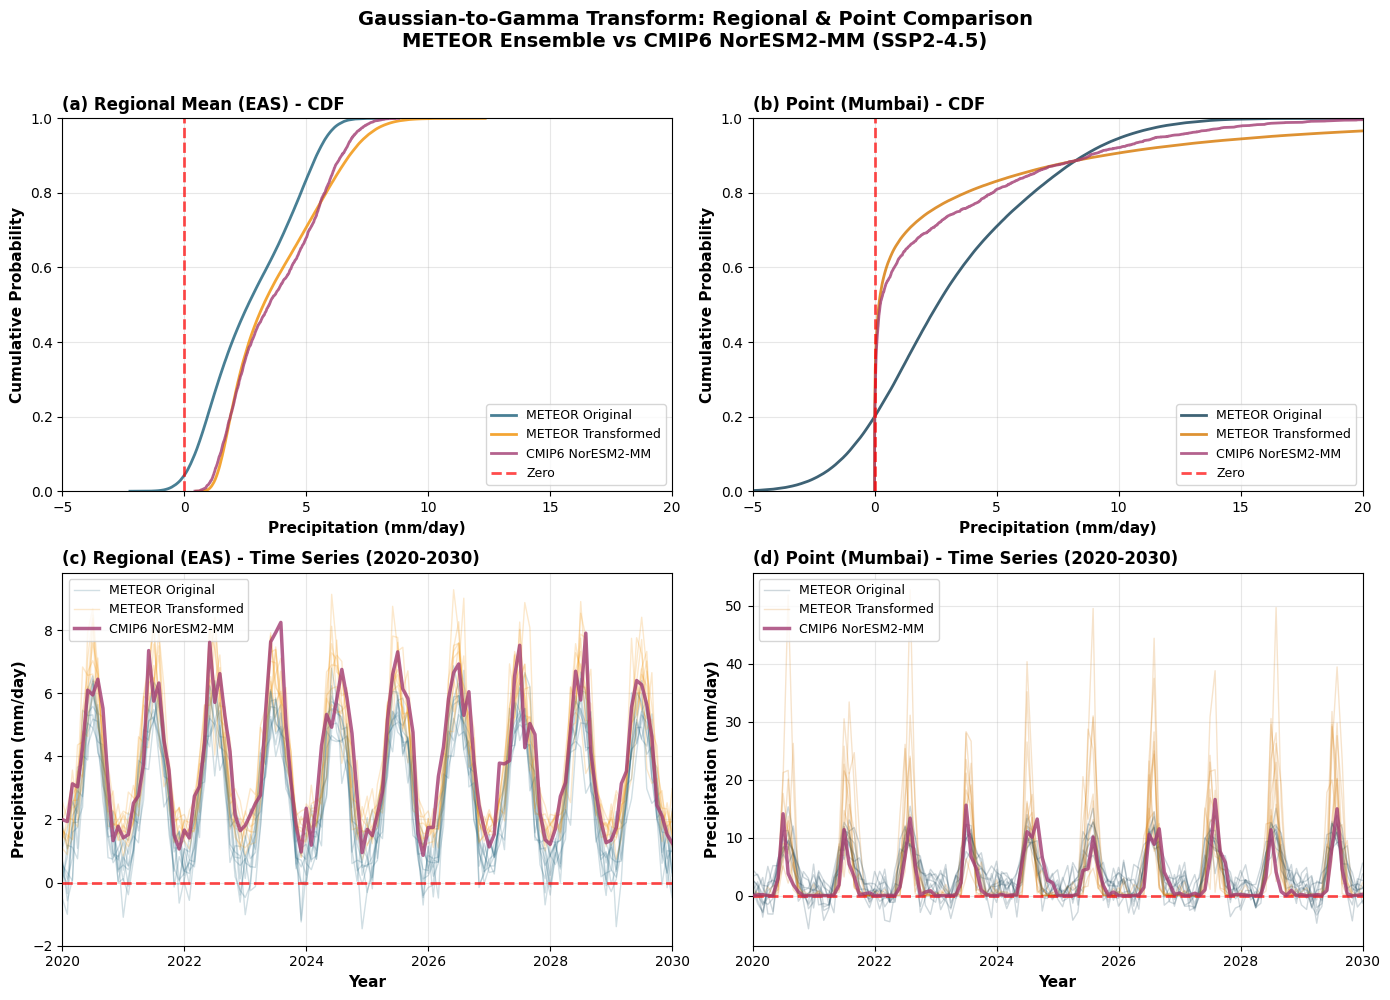


📊 Distribution transform results (Regional & Point):
Scale           Negative→0      Mean (orig)     Mean (γ)       
----------------------------------------------------------------------
Regional (EAS)  17980           2.807           3.787          
Point (Mumbai)  84256           3.200           2.902          

✅ Transform successfully eliminated 102236 negative values!
   CMIP6 overlay shows target distribution to match


In [143]:
# Comparison plot: Regional and Point only (with CMIP6 overlay)
if min_regional < 0 or min_point < 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors_orig = {'regional': '#1A5F7A', 'point': '#0D3B52'}
    colors_gamma = {'regional': '#F18F01', 'point': '#D67700'}
    colors_cmip = '#A23B72'  # Purple for CMIP6
    
    # Time window: 2020-2030
    zoom_start_cmp, zoom_end_cmp = 2020, 2030
    time_mask_meteor_cmp = (time_axis_meteor >= zoom_start_cmp) & (time_axis_meteor <= zoom_end_cmp)
    time_mask_cmip6_cmp = (time_axis_cmip6 >= zoom_start_cmp) & (time_axis_cmip6 <= zoom_end_cmp)
    
    # ========================================================================
    # ROW 1: CDFs (Distribution Comparison with CMIP6)
    # ========================================================================
    
    # Panel 1: Regional Mean CDF
    ax = axes[0, 0]
    
    # Calculate CDFs for regional data
    sorted_regional_orig = np.sort(pr_regional_ensemble_mm.values.flatten())
    cdf_regional_orig = np.arange(1, len(sorted_regional_orig) + 1) / len(sorted_regional_orig)
    
    sorted_regional_gamma = np.sort(pr_regional_ensemble_mm_gamma.values.flatten())
    cdf_regional_gamma = np.arange(1, len(sorted_regional_gamma) + 1) / len(sorted_regional_gamma)
    
    sorted_regional_cmip = np.sort(original_pr_regional_mm.values.flatten())
    cdf_regional_cmip = np.arange(1, len(sorted_regional_cmip) + 1) / len(sorted_regional_cmip)
    
    # Plot CDFs
    ax.plot(sorted_regional_orig, cdf_regional_orig, 
            label='METEOR Original', color=colors_orig['regional'], linewidth=2, alpha=0.8)
    ax.plot(sorted_regional_gamma, cdf_regional_gamma,
            label='METEOR Transformed', color=colors_gamma['regional'], linewidth=2, alpha=0.8)
    ax.plot(sorted_regional_cmip, cdf_regional_cmip,
            label=f'CMIP6 {pr_model_name}', color=colors_cmip, linewidth=2, alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero')
    ax.set_xlabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Cumulative Probability', fontweight='bold', fontsize=11)
    ax.set_title(f'(a) Regional Mean ({region_name}) - CDF', fontweight='bold', loc='left', fontsize=12)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 20)
    ax.set_ylim(0, 1)
    
    # Panel 2: Point Location CDF
    ax = axes[0, 1]
    
    # Calculate CDFs for point data
    sorted_point_orig = np.sort(pr_point_ensemble_mm.values.flatten())
    cdf_point_orig = np.arange(1, len(sorted_point_orig) + 1) / len(sorted_point_orig)
    
    sorted_point_gamma = np.sort(pr_point_ensemble_mm_gamma.values.flatten())
    cdf_point_gamma = np.arange(1, len(sorted_point_gamma) + 1) / len(sorted_point_gamma)
    
    sorted_point_cmip = np.sort(original_pr_point_mm.values.flatten())
    cdf_point_cmip = np.arange(1, len(sorted_point_cmip) + 1) / len(sorted_point_cmip)
    
    # Plot CDFs
    ax.plot(sorted_point_orig, cdf_point_orig,
            label='METEOR Original', color=colors_orig['point'], linewidth=2, alpha=0.8)
    ax.plot(sorted_point_gamma, cdf_point_gamma,
            label='METEOR Transformed', color=colors_gamma['point'], linewidth=2, alpha=0.8)
    ax.plot(sorted_point_cmip, cdf_point_cmip,
            label=f'CMIP6 {pr_model_name}', color=colors_cmip, linewidth=2, alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero')
    ax.set_xlabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Cumulative Probability', fontweight='bold', fontsize=11)
    ax.set_title(f'(b) Point ({point_name}) - CDF', fontweight='bold', loc='left', fontsize=12)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 20)
    ax.set_ylim(0, 1)

    # ========================================================================
    # ROW 2: TIME SERIES (2020-2030 with CMIP6 overlay)
    # ========================================================================
    
    # Panel 3: Regional Mean Time Series
    ax = axes[1, 0]
    # Plot METEOR ensemble members
    for i in range(min(10, n_ensemble)):
        ax.plot(time_axis_meteor[time_mask_meteor_cmp],
                pr_regional_ensemble_mm.isel(realization=i).values[time_mask_meteor_cmp],
                color=colors_orig['regional'], alpha=0.2, linewidth=1.0,
                label='METEOR Original' if i == 0 else '')
        ax.plot(time_axis_meteor[time_mask_meteor_cmp],
                pr_regional_ensemble_mm_gamma.isel(realization=i).values[time_mask_meteor_cmp],
                color=colors_gamma['regional'], alpha=0.2, linewidth=1.0,
                label='METEOR Transformed' if i == 0 else '')
    
    # Overlay CMIP6 original data
    ax.plot(time_axis_cmip6[time_mask_cmip6_cmp], 
            original_pr_regional_mm.values[:, time_mask_cmip6_cmp].T,
            color=colors_cmip, linewidth=2.5, linestyle='-', alpha=0.8,
            label=f'CMIP6 {pr_model_name}', zorder=10)
    
    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, zorder=5)
    ax.set_xlabel('Year', fontweight='bold', fontsize=11)
    ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
    ax.set_title(f'(c) Regional ({region_name}) - Time Series (2020-2030)', fontweight='bold', loc='left', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(zoom_start_cmp, zoom_end_cmp)
    
    # Panel 4: Point Location Time Series
    ax = axes[1, 1]
    # Plot METEOR ensemble members
    for i in range(min(10, n_ensemble)):
        ax.plot(time_axis_meteor[time_mask_meteor_cmp],
                pr_point_ensemble_mm.isel(realization=i).values[time_mask_meteor_cmp],
                color=colors_orig['point'], alpha=0.2, linewidth=1.0,
                label='METEOR Original' if i == 0 else '')
        ax.plot(time_axis_meteor[time_mask_meteor_cmp],
                pr_point_ensemble_mm_gamma.isel(realization=i).values[time_mask_meteor_cmp],
                color=colors_gamma['point'], alpha=0.2, linewidth=1.0,
                label='METEOR Transformed' if i == 0 else '')
    
    # Overlay CMIP6 original data
    ax.plot(time_axis_cmip6[time_mask_cmip6_cmp],
            original_pr_point_mm.values[:, time_mask_cmip6_cmp].T,
            color=colors_cmip, linewidth=2.5, linestyle='-', alpha=0.8,
            label=f'CMIP6 {pr_model_name}', zorder=10)
    
    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, zorder=5)
    ax.set_xlabel('Year', fontweight='bold', fontsize=11)
    ax.set_ylabel('Precipitation (mm/day)', fontweight='bold', fontsize=11)
    ax.set_title(f'(d) Point ({point_name}) - Time Series (2020-2030)', fontweight='bold', loc='left', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(zoom_start_cmp, zoom_end_cmp)
    
    plt.suptitle('Gaussian-to-Gamma Transform: Regional & Point Comparison\n' +
                 f'METEOR Ensemble vs CMIP6 {pr_model_name} (SSP2-4.5)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    # Print statistics for regional and point
    print("\n📊 Distribution transform results (Regional & Point):")
    print("="*70)
    print(f"{'Scale':<15} {'Negative→0':<15} {'Mean (orig)':<15} {'Mean (γ)':<15}")
    print("-"*70)
    
    neg_regional = (pr_regional_ensemble_mm.values < 0).sum()
    neg_point = (pr_point_ensemble_mm.values < 0).sum()
    
    print(f"{f'Regional ({region_name})':<15} {neg_regional:<15} "
          f"{pr_regional_ensemble_mm.mean().values:<15.3f} "
          f"{pr_regional_ensemble_mm_gamma.mean().values:<15.3f}")
    
    print(f"{f'Point ({point_name})':<15} {neg_point:<15} "
          f"{pr_point_ensemble_mm.mean().values:<15.3f} "
          f"{pr_point_ensemble_mm_gamma.mean().values:<15.3f}")
    
    print("="*70)
    print(f"\n✅ Transform successfully eliminated {neg_regional + neg_point} negative values!")
    print(f"   CMIP6 overlay shows target distribution to match")